# Phương pháp 1 — Conformal chuẩn hoá, từ đầu đến cuối

## Cơ chế

Trên tập **calibration** (615.908 chuyến model chưa từng thấy), đo sai số tương đối của từng chuyến:

$$e_i = \frac{|\hat p_i - y_i|}{\hat p_i}$$

Lấy phân vị `α` của tập `{e_i}` làm `q`, rồi dựng khoảng cho chuyến mới:

$$[\hat p \times (1 - q),\ \hat p \times (1 + q)]$$

**Vì sao chia cho `p̂` (chuẩn hoá):** nếu dùng sai số tuyệt đối thì mọi chuyến nhận cùng một khoảng
tính bằng đồng — vô lý, vì chuyến 300k sai 30k là bình thường còn chuyến 50k sai 30k là thảm hoạ.
Chia cho `p̂` khiến khoảng **co giãn theo giá**.

## Bảo đảm

Conformal cho bảo đảm **hữu hạn mẫu, phân phối tự do**: với `n` chuyến calibration, coverage trên
dữ liệu mới đảm bảo ≥ `α` bất kể phân phối dữ liệu ra sao và model tốt hay tệ. Không cần giả định
sai số phân phối chuẩn.

Điều kiện duy nhất: chuyến calibration và chuyến mới phải **hoán đổi được** (exchangeable).

## Nội dung notebook

| Phần | Nội dung | Hình |
|---|---|---|
| 1 | Dựng khoảng, kiểm coverage ở mức 90% | `UQ1` `UQ2` |
| 2 | Ba mức tin cậy 70 / 80 / 90% — chọn mức nào | `TC1`–`TC4` |
| 3 | Phân rã theo **quãng đường** + Mondrian | `MD1`–`MD6` |
| 4 | Phân rã theo **band giá** + Mondrian | `BG1`–`BG4` |

> Phần 3 và 4 là cùng một kỹ thuật (**Mondrian conformal** — hiệu chỉnh `q` riêng từng nhóm) áp
> lên hai chiều khác nhau. Đọc phần 3 trước để hiểu kỹ thuật, phần 4 là nơi nó tạo khác biệt lớn nhất.

---

# 1. Dựng khoảng và kiểm coverage

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK, LIGHT = "#222222", "#CCCCCC"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC = 0.90                      # muc tin cay muc tieu
print(f"Muc tin cay muc tieu: {MUC*100:.0f}%")

Muc tin cay muc tieu: 90%


## 1. Nạp dự đoán trên CALIBRATION và TEST

In [2]:
cal = pd.read_parquet("../evaluation/uq_pred_calibration.parquet")
tes = pd.read_parquet("../evaluation/uq_pred_test.parquet")

for ten, df in [("CALIBRATION", cal), ("TEST", tes)]:
    mae = np.abs(df.hybrid_pred - df.gia_that).mean()
    mape = (np.abs(df.hybrid_pred - df.gia_that) / df.gia_that).mean() * 100
    print(f"{ten:12s}: {len(df):>9,} dong | MAE {mae:>10,.0f}d | MAPE {mape:5.2f}%")

print()
print("Phan bo theo thang:")
print(pd.crosstab(cal.evaluation_month, cal.split).join(
      pd.crosstab(tes.evaluation_month, tes.split)).to_string())

CALIBRATION :   615,908 dong | MAE     17,161d | MAPE 14.74%
TEST        :   864,360 dong | MAE     18,048d | MAPE 14.74%

Phan bo theo thang:
split             calibration    test
evaluation_month                     
2026-01                229504  315360
2026-02                154280  234632
2026-03                232124  314368


## 2. Phần dư trên CALIBRATION — tuyệt đối vs tương đối

Đây là bước quyết định: nhìn xem sai số **tuyệt đối** hay **tương đối** mới ổn định.

In [3]:
cal["sai_so"] = cal.hybrid_pred - cal.gia_that
cal["sai_so_abs"] = np.abs(cal.sai_so)
cal["sai_so_rel"] = cal.sai_so_abs / cal.hybrid_pred      # chuan hoa theo gia DU DOAN

cal["dai_km"] = pd.cut(cal.quote_distance, [0, 3, 5, 7, 10, 100],
                       labels=["<3km", "3-5km", "5-7km", "7-10km", ">10km"])

g = cal.groupby("dai_km").agg(
    n=("sai_so_abs", "size"),
    gia_TB=("gia_that", "mean"),
    saiso_tuyetdoi=("sai_so_abs", "mean"),
    saiso_tuongdoi=("sai_so_rel", "mean"))
g["saiso_tuongdoi"] = (g.saiso_tuongdoi * 100).round(2)
print("SAI SO THEO DAI QUANG DUONG (tap calibration):")
display(g.round(0))

cv_abs = cal.groupby("dai_km").sai_so_abs.mean().std() / cal.groupby("dai_km").sai_so_abs.mean().mean()
cv_rel = cal.groupby("dai_km").sai_so_rel.mean().std() / cal.groupby("dai_km").sai_so_rel.mean().mean()
print(f"\nDo bien thien giua cac dai (he so bien thien):")
print(f"  Sai so TUYET DOI : {cv_abs*100:5.1f}%")
print(f"  Sai so TUONG DOI : {cv_rel*100:5.1f}%   <- on dinh hon nhieu")
print("\n=> Xac nhan: nen dung khoang theo % (conformal chuan hoa).")

SAI SO THEO DAI QUANG DUONG (tap calibration):


,n,gia_TB,saiso_tuyetdoi,saiso_tuongdoi
dai_km,,,,
<3km,40864,58526.0,6112.0,11.0
3-5km,59712,88348.0,12893.0,15.0
5-7km,283576,106171.0,15631.0,15.0
7-10km,203496,143989.0,21223.0,15.0
>10km,28260,189685.0,28249.0,15.0



Do bien thien giua cac dai (he so bien thien):
  Sai so TUYET DOI :  49.9%
  Sai so TUONG DOI :  13.7%   <- on dinh hon nhieu

=> Xac nhan: nen dung khoang theo % (conformal chuan hoa).


## 3. Ba phương pháp Conformal

In [4]:
# ============ PP1: Conformal co ban — khoang CO DINH ============
q_abs = np.quantile(cal.sai_so_abs, MUC)
print(f"PP1 — Conformal co ban")
print(f"  Nguong q = phan vi {MUC*100:.0f}% cua sai so tuyet doi = {q_abs:,.0f}d")
print(f"  Khoang: [y_hat - {q_abs:,.0f}, y_hat + {q_abs:,.0f}]  (moi chuyen NHU NHAU)")

# ============ PP2: Conformal CHUAN HOA — khoang theo % ============
q_rel = np.quantile(cal.sai_so_rel, MUC)
print(f"\nPP2 — Conformal chuan hoa")
print(f"  Nguong q = phan vi {MUC*100:.0f}% cua sai so tuong doi = {q_rel*100:.2f}%")
print(f"  Khoang: [y_hat x (1-{q_rel:.4f}), y_hat x (1+{q_rel:.4f})]  (CO GIAN theo gia)")

# ============ PP3: Conformal THEO NHOM (Mondrian) ============
def khung_gio(h):
    if h < 5:  return "0. Dem khuya"
    if h < 7:  return "1. Sang som"
    if h < 9:  return "2. Cao diem sang"
    if h < 16: return "3. Giua ngay"
    if h < 19: return "4. Cao diem chieu"
    return "5. Toi"

cal["khung"] = cal.gio_vn.apply(khung_gio)
tes["khung"] = tes.gio_vn.apply(khung_gio)
q_nhom = cal.groupby("khung").sai_so_rel.quantile(MUC)
print(f"\nPP3 — Conformal theo nhom (moi khung gio mot nguong)")
for k, v in q_nhom.items():
    print(f"    {k:20s}: {v*100:5.2f}%")

PP1 — Conformal co ban
  Nguong q = phan vi 90% cua sai so tuyet doi = 36,805d
  Khoang: [y_hat - 36,805, y_hat + 36,805]  (moi chuyen NHU NHAU)

PP2 — Conformal chuan hoa
  Nguong q = phan vi 90% cua sai so tuong doi = 30.09%
  Khoang: [y_hat x (1-0.3009), y_hat x (1+0.3009)]  (CO GIAN theo gia)



PP3 — Conformal theo nhom (moi khung gio mot nguong)
    0. Dem khuya        : 30.09%
    1. Sang som         : 30.34%
    2. Cao diem sang    : 30.28%
    3. Giua ngay        : 30.08%
    4. Cao diem chieu   : 29.90%
    5. Toi              : 30.04%


## 4. Áp lên TEST và đo Coverage

In [5]:
tes["low_1"]  = tes.hybrid_pred - q_abs
tes["high_1"] = tes.hybrid_pred + q_abs

tes["low_2"]  = tes.hybrid_pred * (1 - q_rel)
tes["high_2"] = tes.hybrid_pred * (1 + q_rel)

qn = tes.khung.map(q_nhom)
tes["low_3"]  = tes.hybrid_pred * (1 - qn)
tes["high_3"] = tes.hybrid_pred * (1 + qn)

def danh_gia(lo, hi, ten):
    phu = ((tes.gia_that >= lo) & (tes.gia_that <= hi)).mean()
    rong = (hi - lo).mean()
    rong_rel = ((hi - lo) / tes.gia_that).mean()
    return {"Phuong phap": ten, "Coverage": phu, "Do rong TB (d)": rong,
            "Do rong / gia (%)": rong_rel * 100}

kq = pd.DataFrame([
    danh_gia(tes.low_1, tes.high_1, "1. Conformal co ban"),
    danh_gia(tes.low_2, tes.high_2, "2. Conformal chuan hoa"),
    danh_gia(tes.low_3, tes.high_3, "3. Conformal theo nhom"),
])
kq["Coverage"] = (kq.Coverage * 100).round(2)
kq["Lech vs muc tieu"] = (kq.Coverage - MUC*100).round(2)
display(kq.round(1))

print(f"Muc tieu coverage: {MUC*100:.0f}%")
print()
tot = kq.loc[kq["Do rong TB (d)"].idxmin()]
print(f">>> Hep nhat: {tot['Phuong phap']} — {tot['Do rong TB (d)']:,.0f}d "
      f"(coverage {tot['Coverage']:.2f}%)")

,Phuong phap,Coverage,Do rong TB (d),Do rong / gia (%),Lech vs muc tieu
0,1. Conformal co ban,88.6,73610.7,69.1,-1.4
1,2. Conformal chuan hoa,89.6,72629.8,61.1,-0.4
2,3. Conformal theo nhom,89.6,72626.2,61.1,-0.4


Muc tieu coverage: 90%

>>> Hep nhat: 3. Conformal theo nhom — 72,626d (coverage 89.55%)


## 5. ⭐ Conditional Coverage — chỉ số quan trọng nhất

Coverage tổng đạt 90% **chưa đủ**. Phải kiểm tra từng nhóm:

> Nếu giờ cao điểm phủ 78% còn giờ vắng phủ 96%, tổng vẫn ra 90% — nhưng **sai ở cả hai nhóm**.

In [6]:
def cov_theo(cot, ten_cot):
    rows = []
    for nhom, s in tes.groupby(cot, observed=True):
        r = {"Nhom": str(nhom), "n": len(s)}
        for i in [1, 2, 3]:
            r[f"PP{i}"] = ((s.gia_that >= s[f"low_{i}"]) & (s.gia_that <= s[f"high_{i}"])).mean() * 100
        rows.append(r)
    df = pd.DataFrame(rows)
    print(f"\nCOVERAGE THEO {ten_cot.upper()}  (muc tieu {MUC*100:.0f}%)")
    display(df.round(2))
    return df

tes["dai_km"] = pd.cut(tes.quote_distance, [0, 3, 5, 7, 10, 100],
                       labels=["<3km", "3-5km", "5-7km", "7-10km", ">10km"])
tes["mua"] = tes.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])

c_gio = cov_theo("khung", "khung gio")
c_dai = cov_theo("dai_km", "dai quang duong")
c_mua = cov_theo("mua", "thoi tiet")

print("\n" + "=" * 62)
print("DO LECH LON NHAT so voi muc tieu (cang nho cang tot)")
print("=" * 62)
for ten, df in [("Khung gio", c_gio), ("Dai quang duong", c_dai), ("Thoi tiet", c_mua)]:
    print(f"  {ten:18s}", end="")
    for i in [1, 2, 3]:
        lech = np.abs(df[f"PP{i}"] - MUC*100).max()
        print(f"  PP{i}: {lech:5.2f}", end="")
    print()
print("\n>>> PP nao co do lech nho nhat o CA BA chieu la tot nhat.")


COVERAGE THEO KHUNG GIO  (muc tieu 90%)


,Nhom,n,PP1,PP2,PP3
0,0. Dem khuya,137584,94.98,89.88,89.88
1,1. Sang som,76892,90.47,89.72,90.00
2,2. Cao diem sang,77112,87.58,89.85,90.05
3,3. Giua ngay,266720,87.76,89.64,89.63
4,4. Cao diem chieu,114488,85.47,89.11,88.88
5,5. Toi,191564,86.47,89.29,89.24



COVERAGE THEO DAI QUANG DUONG  (muc tieu 90%)


,Nhom,n,PP1,PP2,PP3
0,<3km,57968,99.67,94.17,94.17
1,3-5km,82664,95.76,89.61,89.61
2,5-7km,397492,91.98,89.24,89.24
3,7-10km,286408,82.04,89.16,89.17
4,>10km,39828,69.89,88.67,88.65



COVERAGE THEO THOI TIET  (muc tieu 90%)


,Nhom,n,PP1,PP2,PP3
0,False,473332,89.74,89.6,89.59
1,True,391028,87.10,89.5,89.51



DO LECH LON NHAT so voi muc tieu (cang nho cang tot)
  Khung gio           PP1:  4.98  PP2:  0.89  PP3:  1.12
  Dai quang duong     PP1: 20.11  PP2:  4.17  PP3:  4.17
  Thoi tiet           PP1:  2.90  PP2:  0.50  PP3:  0.49

>>> PP nao co do lech nho nhat o CA BA chieu la tot nhat.


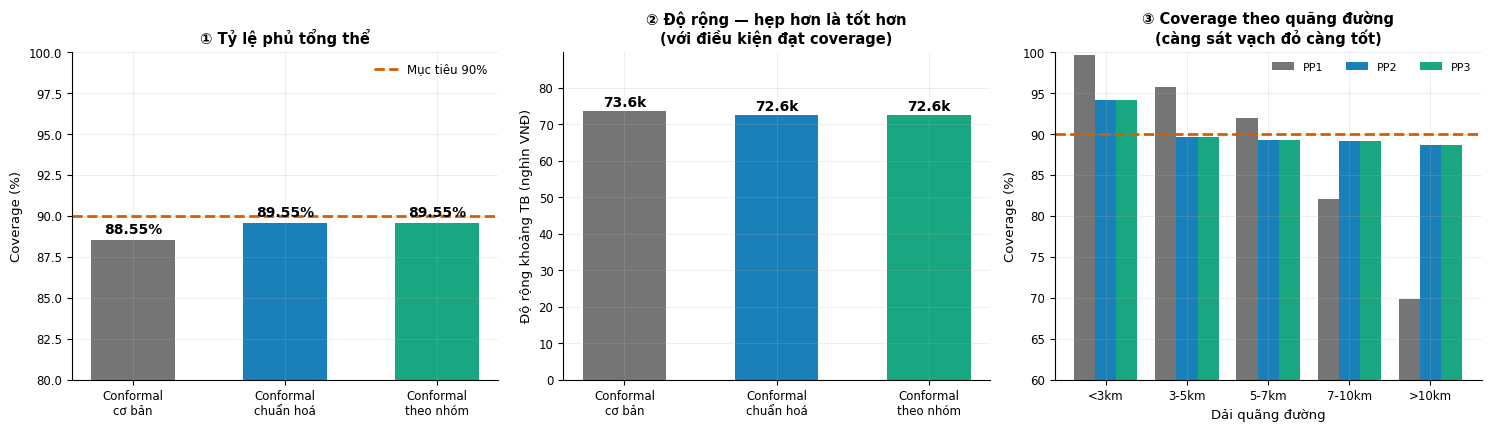

In [7]:
# ═════════ HINH U1 — so sanh 3 phuong phap ═════════
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
TEN_PP = ["Conformal\ncơ bản", "Conformal\nchuẩn hoá", "Conformal\ntheo nhóm"]
MAU = [MUT, BLUE, GREEN]

# (a) Coverage tong
cov = kq.Coverage.values
b_ = ax[0].bar(range(3), cov, color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b_, cov):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+0.4, f"{v:.2f}%", ha="center",
               fontsize=10, fontweight="bold")
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--", label=f"Mục tiêu {MUC*100:.0f}%")
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(TEN_PP, fontsize=8.5)
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(80, 100)
ax[0].set_title("① Tỷ lệ phủ tổng thể", fontweight="bold"); ax[0].legend(frameon=False)

# (b) Do rong
rong = kq["Do rong TB (d)"].values / 1000
b2 = ax[1].bar(range(3), rong, color=MAU, alpha=0.9, width=0.55)
for bb, v in zip(b2, rong):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+1.2, f"{v:.1f}k", ha="center",
               fontsize=10, fontweight="bold")
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(TEN_PP, fontsize=8.5)
ax[1].set_ylabel("Độ rộng khoảng TB (nghìn VNĐ)")
ax[1].set_title("② Độ rộng — hẹp hơn là tốt hơn\n(với điều kiện đạt coverage)", fontweight="bold")
ax[1].set_ylim(0, max(rong)*1.22)

# (c) Conditional coverage theo dai quang duong
x = np.arange(len(c_dai)); w = 0.26
for i, (col, ten) in enumerate(zip(MAU, ["PP1", "PP2", "PP3"])):
    ax[2].bar(x + (i-1)*w, c_dai[f"PP{i+1}"], w, color=col, alpha=0.9, label=ten)
ax[2].axhline(MUC*100, color=RED, lw=2, ls="--")
ax[2].set_xticks(x); ax[2].set_xticklabels(c_dai.Nhom, fontsize=8.5)
ax[2].set_xlabel("Dải quãng đường"); ax[2].set_ylabel("Coverage (%)")
ax[2].set_title("③ Coverage theo quãng đường\n(càng sát vạch đỏ càng tốt)", fontweight="bold")
ax[2].set_ylim(60, 100); ax[2].legend(frameon=False, ncol=3, fontsize=8)

plt.tight_layout(); plt.savefig(HINH / "UQ1_so_sanh_conformal.png"); plt.show()

## 6. Ví dụ đọc được — 10 chuyến cụ thể

In [8]:
mau = tes.sample(10, random_state=42).sort_values("gia_that")
bang = pd.DataFrame({
    "Quang duong": mau.quote_distance.round(2).values,
    "Gio": mau.gio_vn.values,
    "Gia THAT": mau.gia_that.round(0).values,
    "Du doan": mau.hybrid_pred.round(0).values,
    "Khoang PP2 (chuan hoa)": [f"[{l:,.0f} - {h:,.0f}]" for l, h in zip(mau.low_2, mau.high_2)],
    "Do rong": (mau.high_2 - mau.low_2).round(0).values,
    "Co phu?": np.where((mau.gia_that >= mau.low_2) & (mau.gia_that <= mau.high_2), "CO", "KHONG"),
})
display(bang)
print(f"Trong 10 chuyen nay: phu {(bang['Co phu?']=='CO').sum()}/10")

,Quang duong,Gio,Gia THAT,Du doan,Khoang PP2 (chuan hoa),Do rong,Co phu?
0,5.14,4,57000.0,77104.0,"[53,904 - 100,305]",46401.0,CO
1,5.00,17,76000.0,110447.0,"[77,214 - 143,681]",66467.0,KHONG
2,8.96,17,107000.0,173514.0,"[121,303 - 225,724]",104420.0,KHONG
3,6.29,9,118000.0,113507.0,"[79,353 - 147,661]",68308.0,CO
4,5.33,11,126000.0,137709.0,"[96,272 - 179,145]",82873.0,CO
5,13.18,1,138000.0,161392.0,"[112,829 - 209,955]",97126.0,CO
6,5.36,14,145000.0,103538.0,"[72,384 - 134,693]",62309.0,KHONG
7,6.12,0,145000.0,120789.0,"[84,443 - 157,134]",72690.0,CO
8,5.66,19,192000.0,148522.0,"[103,832 - 193,213]",89381.0,CO
9,8.14,19,215000.0,199309.0,"[139,337 - 259,281]",119944.0,CO


Trong 10 chuyen nay: phu 7/10


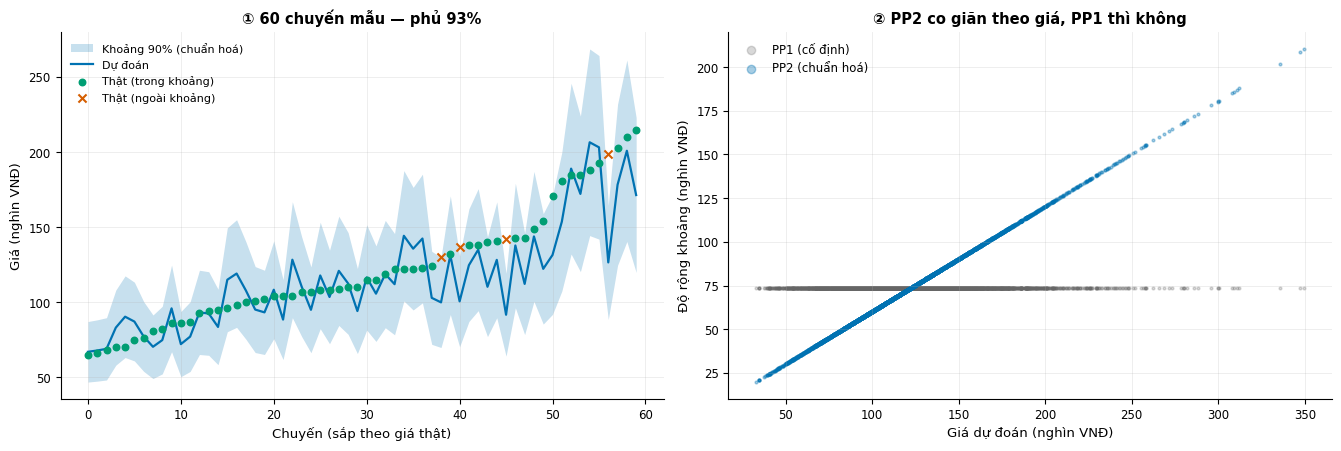

In [9]:
# ═════════ HINH U2 — truc quan khoang du doan ═════════
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))

# (a) 60 chuyen dau, sap theo gia that
s = tes.sample(60, random_state=7).sort_values("gia_that").reset_index(drop=True)
i = np.arange(len(s))
ax[0].fill_between(i, s.low_2/1000, s.high_2/1000, color=BLUE, alpha=0.22, lw=0,
                   label="Khoảng 90% (chuẩn hoá)")
ax[0].plot(i, s.hybrid_pred/1000, color=BLUE, lw=1.6, label="Dự đoán")
trong = (s.gia_that >= s.low_2) & (s.gia_that <= s.high_2)
ax[0].scatter(i[trong], s.gia_that[trong]/1000, s=22, color=GREEN, zorder=5, label="Thật (trong khoảng)")
ax[0].scatter(i[~trong], s.gia_that[~trong]/1000, s=34, color=RED, marker="x", zorder=5,
              label="Thật (ngoài khoảng)")
ax[0].set_xlabel("Chuyến (sắp theo giá thật)"); ax[0].set_ylabel("Giá (nghìn VNĐ)")
ax[0].set_title(f"① 60 chuyến mẫu — phủ {trong.mean()*100:.0f}%", fontweight="bold")
ax[0].legend(frameon=False, fontsize=8)

# (b) Do rong khoang theo gia du doan
ax[1].scatter(tes.hybrid_pred.sample(4000, random_state=1)/1000,
              (tes.high_1 - tes.low_1).sample(4000, random_state=1)/1000,
              s=4, alpha=0.25, color=MUT, label="PP1 (cố định)")
ax[1].scatter(tes.hybrid_pred.sample(4000, random_state=1)/1000,
              (tes.high_2 - tes.low_2).sample(4000, random_state=1)/1000,
              s=4, alpha=0.35, color=BLUE, label="PP2 (chuẩn hoá)")
ax[1].set_xlabel("Giá dự đoán (nghìn VNĐ)"); ax[1].set_ylabel("Độ rộng khoảng (nghìn VNĐ)")
ax[1].set_title("② PP2 co giãn theo giá, PP1 thì không", fontweight="bold")
ax[1].legend(frameon=False, markerscale=3)

plt.tight_layout(); plt.savefig(HINH / "UQ2_khoang_du_doan.png"); plt.show()

## 7. Kết luận

In [10]:
print("=" * 66)
print("TOM TAT UNCERTAINTY QUANTIFICATION")
print("=" * 66)
best = kq.iloc[kq["Do rong TB (d)"].idxmin()]
print(f"  Muc tin cay muc tieu : {MUC*100:.0f}%")
print()
for _, r in kq.iterrows():
    print(f"  {r['Phuong phap']:26s} coverage {r['Coverage']:6.2f}%  "
          f"| rong {r['Do rong TB (d)']:>9,.0f}d ({r['Do rong / gia (%)']:.1f}% gia)")
print()
print(f"  Nguong chuan hoa: +/- {q_rel*100:.2f}% quanh gia du doan")
print(f"  Vi du: du doan 114.000d -> khoang [{114000*(1-q_rel):,.0f} - {114000*(1+q_rel):,.0f}]")

TOM TAT UNCERTAINTY QUANTIFICATION
  Muc tin cay muc tieu : 90%

  1. Conformal co ban        coverage  88.55%  | rong    73,611d (69.1% gia)
  2. Conformal chuan hoa     coverage  89.55%  | rong    72,630d (61.1% gia)
  3. Conformal theo nhom     coverage  89.55%  | rong    72,626d (61.1% gia)

  Nguong chuan hoa: +/- 30.09% quanh gia du doan
  Vi du: du doan 114.000d -> khoang [79,697 - 148,303]


---

# 2. Chọn mức tin cậy

Mức 90% là mặc định, nhưng không phải lúc nào cũng đúng. Phần này đo **cái giá** của từng mức: hạ mức tin cậy thì khoảng hẹp lại bao nhiêu, đổi lại trượt thêm bao nhiêu.

In [11]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

cal = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
tes = pd.read_parquet(EVAL / "uq_pred_test.parquet")
sai_cal = ((cal.hybrid_pred - cal.gia_that).abs() / cal.hybrid_pred).values

# ═══ Ba muc dem so sanh ═══
MUCS_SS = [0.70, 0.80, 0.90]
MAU_SS = {0.70: PURPLE, 0.80: ORANGE, 0.90: RED}
GOC = 0.90                      # moc so sanh


def dung_khoang(muc):
    q = np.quantile(sai_cal, muc)
    lo = tes.hybrid_pred * (1 - q)
    hi = tes.hybrid_pred * (1 + q)
    trong = (tes.gia_that >= lo) & (tes.gia_that <= hi)
    return dict(muc=muc, q=q, lo=lo, hi=hi, trong=trong,
                cov=trong.mean(), rong=(hi - lo).mean())


K = {m: dung_khoang(m) for m in MUCS_SS}
G = K[GOC]

print(f"Calibration {len(cal):,} | Test {len(tes):,}")
print()
print(f"{'Muc':>6s} {'q (±%)':>9s} {'Coverage':>10s} {'Do rong TB':>13s} "
      f"{'vs 90%':>9s} {'Truot/1.000':>12s}")
print("-" * 64)
for m in MUCS_SS:
    r = K[m]
    print(f"{m:>5.0%} {r['q']:>9.2%} {r['cov']:>10.2%} {r['rong']:>12,.0f}d "
          f"{r['rong']/G['rong']-1:>+8.1%} {(1-r['cov'])*1000:>12.0f}")

Calibration 615,908 | Test 864,360

   Muc    q (±%)   Coverage    Do rong TB    vs 90%  Truot/1.000
----------------------------------------------------------------
  70%    18.78%     69.73%       45,320d   -37.6%          303
  80%    23.25%     79.60%       56,118d   -22.7%          204
  90%    30.09%     89.55%       72,630d    +0.0%          104


## 1. Quét toàn dải mức tin cậy

Quan hệ **không tuyến tính** — càng gần 100% thì độ rộng càng bùng nổ, càng xuống thấp thì mỗi
điểm % coverage đổi được càng ít độ rộng.

In [12]:
MUCS = np.array([0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.98, 0.99])
rows = []
for m in MUCS:
    r = dung_khoang(m)
    rows.append({
        "Mức tin cậy": f"{m:.0%}",
        "q (±%)": f"{r['q']:.2%}",
        "Coverage đạt": f"{r['cov']:.2%}",
        "Độ rộng TB (đ)": round(r["rong"]),
        "So với 90%": f"{r['rong']/G['rong']-1:+.1%}",
        "Trượt / 1.000": round((1-r["cov"])*1000),
    })
BANG = pd.DataFrame(rows)


def to_dam(s):
    return ["font-weight:700" if v in ("70%", "80%", "90%") else "" for v in s]


display(BANG.style.apply(to_dam, subset=["Mức tin cậy"]).hide(axis="index"))

Mức tin cậy,q (±%),Coverage đạt,Độ rộng TB (đ),So với 90%,Trượt / 1.000
50%,12.14%,49.73%,29298,-59.7%,503
60%,15.19%,59.70%,36667,-49.5%,403
70%,18.78%,69.73%,45320,-37.6%,303
75%,20.87%,74.70%,50378,-30.6%,253
80%,23.25%,79.60%,56118,-22.7%,204
85%,26.16%,84.53%,63134,-13.1%,155
90%,30.09%,89.55%,72630,+0.0%,104
95%,36.50%,94.63%,88090,+21.3%,54
98%,45.71%,97.82%,110342,+51.9%,22
99%,52.83%,98.89%,127512,+75.6%,11


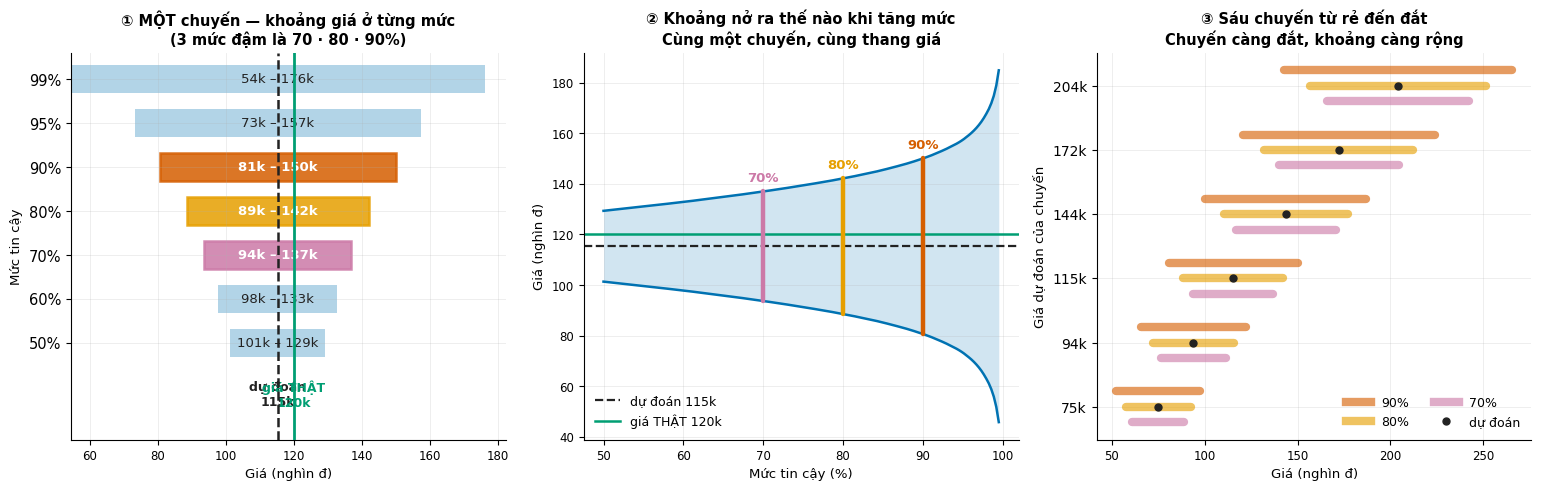

CHUYEN VI DU — gia du doan 115,335d  (gia that 120,000d)
   Muc                 Khoang gia       Do rong
----------------------------------------------------------
  50%      101,335 -     129,334d       27,999d
  60%       97,814 -     132,855d       35,041d
  70%       93,680 -     136,990d       43,310d <<<
  80%       88,520 -     142,149d       53,629d <<<
  90%       80,631 -     150,039d       69,408d <<<
  95%       73,243 -     157,426d       84,183d
  99%       54,407 -     176,263d      121,857d


In [13]:
# ═════════ HINH TC1 — KHOANG GIA THAT theo tung muc tin cay ═════════
MUC_THANG = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]

# Chon 1 chuyen co gia du doan gan trung vi de lam vi du
i_vd = int(np.argsort(np.abs(tes.hybrid_pred.values -
                             np.median(tes.hybrid_pred.values)))[0])
p_vd = tes.hybrid_pred.values[i_vd]
that_vd = tes.gia_that.values[i_vd]

fig, ax = plt.subplots(1, 3, figsize=(15.5, 5.0))

# ── (a) MOT chuyen: khoang gia o 7 muc ──
for j, m in enumerate(MUC_THANG):
    q = np.quantile(sai_cal, m)
    lo, hi = p_vd*(1-q), p_vd*(1+q)
    col = MAU_SS.get(m, BLUE)
    dam = m in MUCS_SS
    ax[0].barh(j, (hi-lo)/1000, left=lo/1000, height=.62, color=col,
               alpha=.85 if dam else .30,
               edgecolor=col if dam else "none", linewidth=1.8 if dam else 0)
    ax[0].text((lo+hi)/2000, j, f"{lo/1000:.0f}k – {hi/1000:.0f}k",
               ha="center", va="center", fontsize=9.5,
               fontweight="bold" if dam else "normal",
               color="white" if dam else INK)
# Hai vach moc: du doan va gia that — nhan dat o DAY de khong de tieu de
ax[0].axvline(p_vd/1000, color=INK, lw=1.8, ls="--", zorder=5)
ax[0].axvline(that_vd/1000, color=GREEN, lw=2.0, zorder=5)
ax[0].text(p_vd/1000, -0.85, f"dự đoán\n{p_vd/1000:.0f}k", ha="center", va="top",
           fontsize=9, fontweight="bold", color=INK)
ax[0].text(that_vd/1000, -0.85, f"giá THẬT\n{that_vd/1000:.0f}k", ha="center",
           va="top", fontsize=9, fontweight="bold", color=GREEN)
ax[0].set_yticks(range(len(MUC_THANG)))
ax[0].set_yticklabels([f"{m:.0%}" for m in MUC_THANG], fontsize=10.5)
ax[0].set_ylim(-2.2, len(MUC_THANG)-0.4)
ax[0].set_xlabel("Giá (nghìn đ)"); ax[0].set_ylabel("Mức tin cậy")
ax[0].set_title("① MỘT chuyến — khoảng giá ở từng mức\n(3 mức đậm là 70 · 80 · 90%)",
                fontweight="bold", fontsize=10.5)

# ── (b) Hinh quat: khoang mo rong lien tuc theo muc ──
mm = np.linspace(.50, .995, 160)
qq = np.array([np.quantile(sai_cal, m) for m in mm])
lo_c, hi_c = p_vd*(1-qq)/1000, p_vd*(1+qq)/1000
ax[1].fill_between(mm*100, lo_c, hi_c, color=BLUE, alpha=.18, lw=0)
ax[1].plot(mm*100, lo_c, color=BLUE, lw=1.8)
ax[1].plot(mm*100, hi_c, color=BLUE, lw=1.8)
ax[1].axhline(p_vd/1000, color=INK, lw=1.6, ls="--", label=f"dự đoán {p_vd/1000:.0f}k")
ax[1].axhline(that_vd/1000, color=GREEN, lw=1.8, label=f"giá THẬT {that_vd/1000:.0f}k")
for m in MUCS_SS:
    q = np.quantile(sai_cal, m)
    ax[1].plot([m*100, m*100], [p_vd*(1-q)/1000, p_vd*(1+q)/1000],
               lw=3.2, color=MAU_SS[m], solid_capstyle="round", zorder=4)
    ax[1].text(m*100, p_vd*(1+q)/1000 + 4, f"{m:.0%}", ha="center",
               fontsize=9.5, fontweight="bold", color=MAU_SS[m])
ax[1].set_xlabel("Mức tin cậy (%)"); ax[1].set_ylabel("Giá (nghìn đ)")
ax[1].legend(frameon=False, fontsize=9, loc="lower left")
ax[1].set_title("② Khoảng nở ra thế nào khi tăng mức\nCùng một chuyến, cùng thang giá",
                fontweight="bold", fontsize=10.5)

# ── (c) Sau chuyen tu re den dat ──
pct = [10, 25, 50, 75, 90, 97]
moc = np.percentile(tes.hybrid_pred.values, pct)
i_ch = [int(np.argsort(np.abs(tes.hybrid_pred.values - v))[0]) for v in moc]
off = {0.90: .24, 0.80: 0.0, 0.70: -.24}
for k_, i_ in enumerate(i_ch):
    p_ = tes.hybrid_pred.values[i_]
    for m in sorted(MUCS_SS, reverse=True):
        q = np.quantile(sai_cal, m)
        ax[2].plot([p_*(1-q)/1000, p_*(1+q)/1000], [k_+off[m]]*2, lw=6,
                   color=MAU_SS[m], alpha=.62, solid_capstyle="round")
    ax[2].plot(p_/1000, k_, "o", color=INK, ms=5, zorder=5)
for m in sorted(MUCS_SS, reverse=True):
    ax[2].plot([], [], lw=6, color=MAU_SS[m], alpha=.62, label=f"{m:.0%}")
ax[2].plot([], [], "o", color=INK, ms=5, label="dự đoán")
ax[2].set_yticks(range(len(i_ch)))
ax[2].set_yticklabels([f"{tes.hybrid_pred.values[i]/1000:.0f}k" for i in i_ch],
                      fontsize=10)
ax[2].set_xlabel("Giá (nghìn đ)"); ax[2].set_ylabel("Giá dự đoán của chuyến")
ax[2].legend(frameon=False, fontsize=9, ncol=2)
ax[2].set_title("③ Sáu chuyến từ rẻ đến đắt\nChuyến càng đắt, khoảng càng rộng",
                fontweight="bold", fontsize=10.5)

plt.tight_layout(); plt.savefig(HINH / "TC1_khoang_gia_theo_muc.png"); plt.show()

print(f"CHUYEN VI DU — gia du doan {p_vd:,.0f}d  (gia that {that_vd:,.0f}d)")
print("=" * 58)
print(f"{'Muc':>6s} {'Khoang gia':>26s} {'Do rong':>13s}")
print("-" * 58)
for m in MUC_THANG:
    q = np.quantile(sai_cal, m)
    lo, hi = p_vd*(1-q), p_vd*(1+q)
    dau_ = " <<<" if m in MUCS_SS else ""
    print(f"{m:>5.0%} {lo:>12,.0f} - {hi:>11,.0f}d {hi-lo:>12,.0f}d{dau_}")

> **Đọc hình:** cùng một chuyến, cùng một model — chỉ đổi mức tin cậy thì khoảng giá nở ra hay
> co lại bấy nhiêu. Sai số của model **không đổi**; ta chỉ **hứa nhiều hay ít** đi.

Ba panel còn lại đo cái giá phải trả và đường đánh đổi:

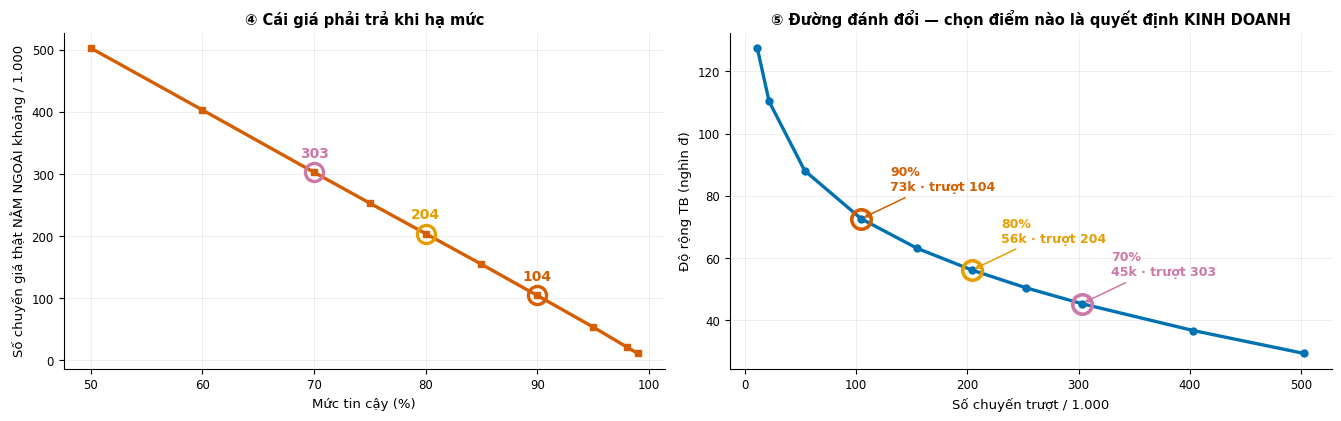

In [14]:
# ═════════ HINH TC1b — cai gia phai tra ═════════
rong = np.array([dung_khoang(m)["rong"] for m in MUCS])
cov = np.array([dung_khoang(m)["cov"] for m in MUCS])

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.3))

ax[0].plot(MUCS*100, (1-cov)*1000, marker="s", lw=2.4, ms=5, color=RED)
for m in MUCS_SS:
    v = (1-K[m]["cov"])*1000
    ax[0].plot(m*100, v, "o", ms=13, mfc="none", mew=2.4, color=MAU_SS[m])
    ax[0].text(m*100, v + 24, f"{v:.0f}", ha="center", fontsize=10,
               fontweight="bold", color=MAU_SS[m])
ax[0].set_xlabel("Mức tin cậy (%)")
ax[0].set_ylabel("Số chuyến giá thật NẰM NGOÀI khoảng / 1.000")
ax[0].set_title("④ Cái giá phải trả khi hạ mức", fontweight="bold", fontsize=10.5)

ax[1].plot((1-cov)*1000, rong/1000, marker="o", lw=2.4, ms=5, color=BLUE, zorder=2)
for m in MUCS_SS:
    r = K[m]
    ax[1].plot((1-r["cov"])*1000, r["rong"]/1000, "o", ms=14, mfc="none", mew=2.6,
               color=MAU_SS[m], zorder=3)
    ax[1].annotate(f"{m:.0%}\n{r['rong']/1000:.0f}k · trượt {(1-r['cov'])*1000:.0f}",
                   xy=((1-r["cov"])*1000, r["rong"]/1000),
                   xytext=((1-r["cov"])*1000+26, r["rong"]/1000+9),
                   fontsize=9, fontweight="bold", color=MAU_SS[m],
                   arrowprops=dict(arrowstyle="->", lw=1.1, color=MAU_SS[m]))
ax[1].set_xlabel("Số chuyến trượt / 1.000"); ax[1].set_ylabel("Độ rộng TB (nghìn đ)")
ax[1].set_title("⑤ Đường đánh đổi — chọn điểm nào là quyết định KINH DOANH",
                fontweight="bold", fontsize=10.5)

plt.tight_layout(); plt.savefig(HINH / "TC1b_cai_gia.png"); plt.show()

## 2. So trực tiếp ba mức

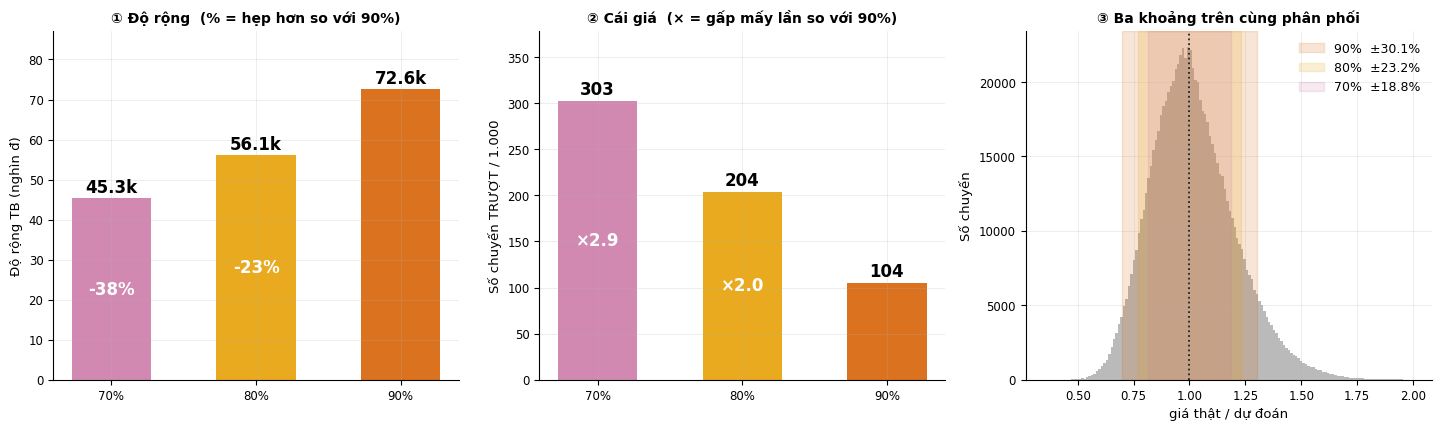

DANH DOI so voi moc 90%
  70% : hep hon 37.6% ( 27,309d)  |  truot gap 2.9 lan (+198/1.000)  |  doi 1 diem coverage = 1.4 nghin d
  80% : hep hon 22.7% ( 16,512d)  |  truot gap 2.0 lan (+100/1.000)  |  doi 1 diem coverage = 1.7 nghin d


In [15]:
# ═════════ HINH TC2 — 70 vs 80 vs 90 ═════════
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))
ten3 = [f"{m:.0%}" for m in MUCS_SS]
mau3 = [MAU_SS[m] for m in MUCS_SS]
rong3 = [K[m]["rong"]/1000 for m in MUCS_SS]
truot3 = [(1-K[m]["cov"])*1000 for m in MUCS_SS]

b = ax[0].bar(ten3, rong3, color=mau3, alpha=.88, width=.55)
for bb, v, m in zip(b, rong3, MUCS_SS):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+1.4, f"{v:.1f}k", ha="center",
               fontsize=12, fontweight="bold")
    if m != GOC:
        ax[0].text(bb.get_x()+bb.get_width()/2, v/2,
                   f"{K[m]['rong']/G['rong']-1:+.0%}", ha="center", va="center",
                   fontsize=12, fontweight="bold", color="white")
ax[0].set_ylabel("Độ rộng TB (nghìn đ)"); ax[0].set_ylim(0, max(rong3)*1.2)
ax[0].set_title("① Độ rộng  (% = hẹp hơn so với 90%)", fontweight="bold", fontsize=10)

b2 = ax[1].bar(ten3, truot3, color=mau3, alpha=.88, width=.55)
for bb, v, m in zip(b2, truot3, MUCS_SS):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+7, f"{v:.0f}", ha="center",
               fontsize=12, fontweight="bold")
    if m != GOC:
        ax[1].text(bb.get_x()+bb.get_width()/2, v/2,
                   f"×{(1-K[m]['cov'])/(1-G['cov']):.1f}", ha="center", va="center",
                   fontsize=12, fontweight="bold", color="white")
ax[1].set_ylabel("Số chuyến TRƯỢT / 1.000"); ax[1].set_ylim(0, max(truot3)*1.25)
ax[1].set_title("② Cái giá  (× = gấp mấy lần so với 90%)", fontweight="bold", fontsize=10)

ax[2].hist((tes.gia_that/tes.hybrid_pred).values, bins=150, range=(.35, 2.0),
           color=MUT, alpha=.45, lw=0)
for m in sorted(MUCS_SS, reverse=True):
    ax[2].axvspan(1-K[m]["q"], 1+K[m]["q"], color=MAU_SS[m], alpha=.16,
                  label=f"{m:.0%}  ±{K[m]['q']:.1%}")
ax[2].axvline(1, color=INK, lw=1.3, ls=":")
ax[2].set_xlabel("giá thật / dự đoán"); ax[2].set_ylabel("Số chuyến")
ax[2].legend(frameon=False, fontsize=9)
ax[2].set_title("③ Ba khoảng trên cùng phân phối", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "TC2_70_80_90.png"); plt.show()

print("=" * 68)
print("DANH DOI so voi moc 90%")
print("=" * 68)
for m in MUCS_SS:
    if m == GOC:
        continue
    r = K[m]
    d_cov = (G["cov"] - r["cov"]) * 100
    print(f"  {m:.0%} : hep hon {abs(r['rong']/G['rong']-1)*100:4.1f}% "
          f"({G['rong']-r['rong']:>7,.0f}d)  |  "
          f"truot gap {(1-r['cov'])/(1-G['cov']):.1f} lan "
          f"(+{(1-r['cov'])*1000-(1-G['cov'])*1000:.0f}/1.000)  |  "
          f"doi 1 diem coverage = {(G['rong']-r['rong'])/1000/d_cov:.1f} nghin d")

## 3. Hạ mức có làm coverage **điều kiện** xấu đi không?

Coverage tổng đạt danh mục là một chuyện. Câu hỏi thật: hạ mức thì **nhóm nào bị thiệt nhiều hơn**?
Nếu độ lệch giữa các nhóm phình ra thì hạ mức tốn thêm một cái giá **ẩn**.

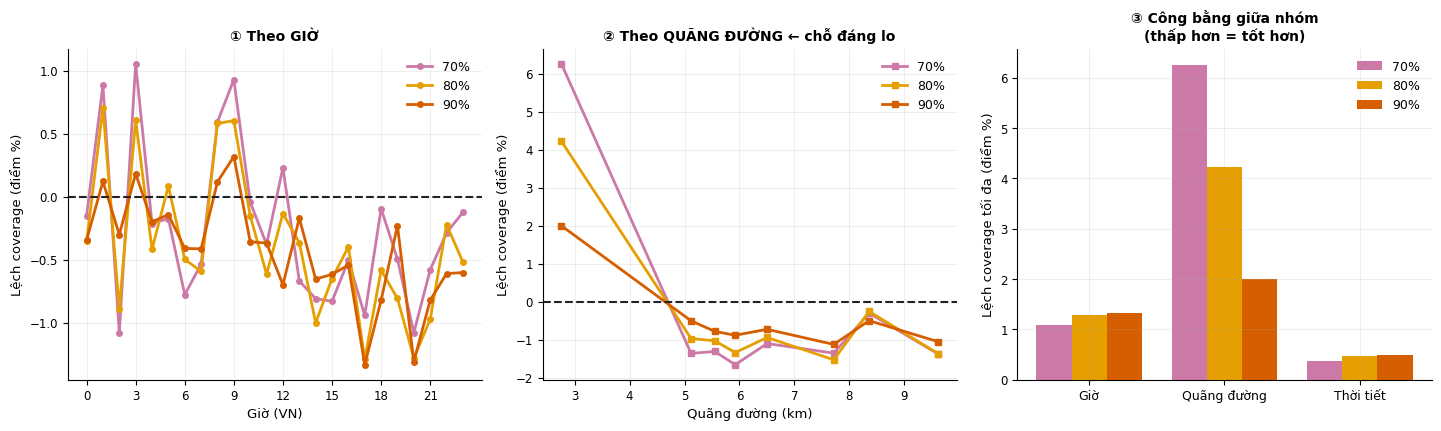

,Mức,Giờ,Quãng đường,Thời tiết,XẤU NHẤT
0,70%,1.08,6.26,0.38,6.26
1,80%,1.29,4.22,0.48,4.22
2,90%,1.33,2.00,0.50,2.00



CAI GIA AN cua viec ha muc — lech coverage TOI DA:
   70% -> 6.26 diem  (chieu quang duong: 6.26)
   80% -> 4.22 diem  (chieu quang duong: 4.22)
   90% -> 2.00 diem  (chieu quang duong: 2.00)

=> Cang ha muc, cong bang giua cac nhom quang duong cang xau.
   Neu chon muc thap, NEN dung kem Mondrian (notebook 04) de bu lai.


In [16]:
# ═════════ HINH TC3 — coverage dieu kien ═════════
t = tes.copy()
for m in MUCS_SS:
    t[f"trong_{int(m*100)}"] = K[m]["trong"].values
t["mua"] = t.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
t["nhom_km"] = pd.qcut(t.quote_distance, 8, labels=False, duplicates="drop")

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

for m in MUCS_SS:
    g = t.groupby("gio_vn")[f"trong_{int(m*100)}"].mean()*100
    ax[0].plot(g.index, g.values - m*100, marker="o", lw=2, ms=4,
               color=MAU_SS[m], label=f"{m:.0%}")
ax[0].axhline(0, color=INK, lw=1.5, ls="--")
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Lệch coverage (điểm %)")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("① Theo GIỜ", fontweight="bold", fontsize=10)

km = t.groupby("nhom_km").quote_distance.median()
for m in MUCS_SS:
    g = t.groupby("nhom_km")[f"trong_{int(m*100)}"].mean()*100
    ax[1].plot(km.values, g.values - m*100, marker="s", lw=2, ms=5,
               color=MAU_SS[m], label=f"{m:.0%}")
ax[1].axhline(0, color=INK, lw=1.5, ls="--")
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("Lệch coverage (điểm %)")
ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title("② Theo QUÃNG ĐƯỜNG ← chỗ đáng lo", fontweight="bold", fontsize=10)

rows_dk = []
for m in MUCS_SS:
    c = f"trong_{int(m*100)}"
    lg = abs(t.groupby("gio_vn")[c].mean()*100 - m*100).max()
    lk = abs(t.groupby("nhom_km")[c].mean()*100 - m*100).max()
    lt = abs(t.groupby("mua")[c].mean()*100 - m*100).max()
    rows_dk.append({"Mức": f"{m:.0%}", "Giờ": round(lg, 2), "Quãng đường": round(lk, 2),
                    "Thời tiết": round(lt, 2), "XẤU NHẤT": round(max(lg, lk, lt), 2)})
DK = pd.DataFrame(rows_dk)

x = np.arange(3); w = .26
for i, m in enumerate(MUCS_SS):
    ax[2].bar(x + (i-1)*w, DK.iloc[i][["Giờ", "Quãng đường", "Thời tiết"]].values, w,
              color=MAU_SS[m], label=f"{m:.0%}")
ax[2].set_xticks(x); ax[2].set_xticklabels(["Giờ", "Quãng đường", "Thời tiết"], fontsize=9)
ax[2].set_ylabel("Lệch coverage tối đa (điểm %)")
ax[2].legend(frameon=False, fontsize=9)
ax[2].set_title("③ Công bằng giữa nhóm\n(thấp hơn = tốt hơn)", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "TC3_coverage_dieu_kien.png"); plt.show()
display(DK)

print("\nCAI GIA AN cua viec ha muc — lech coverage TOI DA:")
for _, r in DK.iterrows():
    print(f"  {r['Mức']:>4s} -> {r['XẤU NHẤT']:.2f} diem  (chieu quang duong: {r['Quãng đường']:.2f})")
print()
print("=> Cang ha muc, cong bang giua cac nhom quang duong cang xau.")
print("   Neu chon muc thap, NEN dung kem Mondrian (notebook 04) de bu lai.")

## 4. Trên chuyến cụ thể thì khác nhau thế nào

Con số trung bình khó hình dung. Đây là khoảng thật cho vài chuyến, tính bằng đồng.

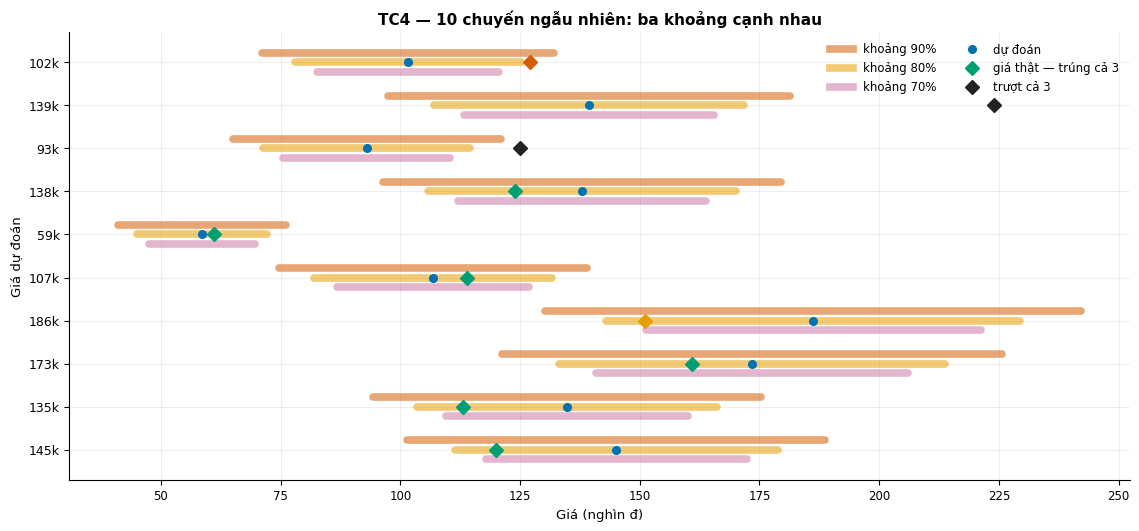

,Dự đoán,Khoảng 70%,Khoảng 80%,Khoảng 90%,Giá thật
0,"145,062đ","117,825 – 172,299","111,336 – 178,788","101,413 – 188,711","120,000đ"
1,"134,827đ","109,512 – 160,142","103,481 – 166,173","94,257 – 175,396","113,000đ"
2,"173,430đ","140,867 – 205,993","133,109 – 213,751","121,245 – 225,615","161,000đ"
3,"186,209đ","151,247 – 221,172","142,917 – 229,502","130,179 – 242,240","151,000đ"
4,"106,825đ","86,767 – 126,882","81,989 – 131,660","74,681 – 138,968","114,000đ"
5,"58,575đ","47,577 – 69,573","44,957 – 72,193","40,950 – 76,200","61,000đ"
6,"137,932đ","112,034 – 163,830","105,864 – 170,000","96,428 – 179,436","124,000đ"
7,"92,955đ","75,502 – 110,408","71,344 – 114,566","64,985 – 120,925","125,000đ"
8,"139,404đ","113,229 – 165,578","106,993 – 171,814","97,457 – 181,350","224,000đ"
9,"101,568đ","82,498 – 120,639","77,955 – 125,182","71,007 – 132,130","127,000đ"


In [17]:
# ═════════ HINH TC4 — chuyen cu the ═════════
rng = np.random.default_rng(7)
n = 10
idx = rng.choice(len(tes), n, replace=False)
s = tes.iloc[idx].reset_index(drop=True)
KH = {m: (s.hybrid_pred*(1-K[m]["q"]), s.hybrid_pred*(1+K[m]["q"])) for m in MUCS_SS}

fig, ax = plt.subplots(figsize=(11.5, 5.4))
off = {0.90: .22, 0.80: 0.0, 0.70: -.22}
for m in sorted(MUCS_SS, reverse=True):
    lo_, hi_ = KH[m]
    for i in range(n):
        ax.plot([lo_[i]/1000, hi_[i]/1000], [i+off[m], i+off[m]], lw=5.5,
                color=MAU_SS[m], alpha=.55, solid_capstyle="round")
for i in range(n):
    ax.plot(s.hybrid_pred[i]/1000, i, "o", color=BLUE, ms=5.5, zorder=4)
    trung = [m for m in MUCS_SS if KH[m][0][i] <= s.gia_that[i] <= KH[m][1][i]]
    c = GREEN if 0.70 in trung else (ORANGE if 0.80 in trung else
                                     (RED if 0.90 in trung else INK))
    ax.plot(s.gia_that[i]/1000, i, "D", ms=7, zorder=5, color=c)
for m in sorted(MUCS_SS, reverse=True):
    ax.plot([], [], lw=5.5, color=MAU_SS[m], alpha=.55, label=f"khoảng {m:.0%}")
ax.plot([], [], "o", color=BLUE, ms=5.5, label="dự đoán")
ax.plot([], [], "D", color=GREEN, ms=7, label="giá thật — trúng cả 3")
ax.plot([], [], "D", color=INK, ms=7, label="trượt cả 3")
ax.set_yticks(range(n))
ax.set_yticklabels([f"{v/1000:.0f}k" for v in s.hybrid_pred], fontsize=9)
ax.set_ylabel("Giá dự đoán"); ax.set_xlabel("Giá (nghìn đ)")
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper right")
ax.set_title("TC4 — 10 chuyến ngẫu nhiên: ba khoảng cạnh nhau",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(HINH / "TC4_chuyen_cu_the.png"); plt.show()

vd = pd.DataFrame({"Dự đoán": [f"{v:,.0f}đ" for v in s.hybrid_pred]})
for m in MUCS_SS:
    lo_, hi_ = KH[m]
    vd[f"Khoảng {m:.0%}"] = [f"{a:,.0f} – {b:,.0f}" for a, b in zip(lo_, hi_)]
vd["Giá thật"] = [f"{v:,.0f}đ" for v in s.gia_that]
display(vd)

## 5. Ảnh hưởng xuống Tầng 3 — câu trả lời có thể gây bất ngờ

Tầng 3 (quyết định giá) **KHÔNG dùng khoảng tin cậy**. Nó lấy tích phân trên **toàn bộ phân phối**:

$$\mathbb{E}[\Pi(p)] = \int (p - MC)\cdot P(\text{chấp nhận})\cdot f(p_{đt})\, dp_{đt}$$

Phân phối `f` **không đổi** khi ta chọn mức tin cậy khác — mức tin cậy chỉ là cách **cắt** phân
phối đó để báo cáo cho người đọc.

In [18]:
P0, EPS, C_CHINH = 0.50, -2.0, 0.50
R_GRID = np.linspace(0.40, 2.00, 1601)
u_cal = (pd.read_parquet(EVAL / "qr_pred_calibration.parquet")
         .pipe(lambda d: d.gia_that / d.q50)).values
u_luoi = np.quantile(u_cal, np.linspace(0.0005, 0.9995, 2000))


def P_accept(r, eps=EPS, P0=P0):
    b = eps/(1-P0); a = np.log(P0/(1-P0))
    return 1/(1+np.exp(-(a + b*np.log(r))))


def toi_uu(u):
    v = np.array([(r-C_CHINH) * P_accept(r/u).mean() for r in R_GRID])
    return R_GRID[int(np.argmax(v))]


print("GIA TOI UU o Tang 3  (c = 50%, eps = -2.0)")
print("=" * 58)
print(f"  Dung TOAN BO phan phoi  ->  r* = {toi_uu(u_luoi):.4f}   <- DUNG")
print()
print("  Neu ai do chi dung khoang da cat (SAI cach):")
for m in MUCS_SS:
    lo_, hi_ = np.quantile(u_cal, [(1-m)/2, 1-(1-m)/2])
    u_cat = u_luoi[(u_luoi >= lo_) & (u_luoi <= hi_)]
    print(f"    khoang {m:.0%}  ->  r* = {toi_uu(u_cat):.4f}")
print()
print("  => Muc tin cay KHONG anh huong quyet dinh gia,")
print("     vi Tang 3 dung ca phan phoi chu khong dung khoang cat.")
print("     No chi anh huong CACH BAO CAO khoang cho nguoi doc.")

GIA TOI UU o Tang 3  (c = 50%, eps = -2.0)
  Dung TOAN BO phan phoi  ->  r* = 1.0410   <- DUNG

  Neu ai do chi dung khoang da cat (SAI cach):
    khoang 70%  ->  r* = 1.0100


    khoang 80%  ->  r* = 1.0160
    khoang 90%  ->  r* = 1.0250

  => Muc tin cay KHONG anh huong quyet dinh gia,
     vi Tang 3 dung ca phan phoi chu khong dung khoang cat.
     No chi anh huong CACH BAO CAO khoang cho nguoi doc.


## Kết luận

In [19]:
print("╔" + "═"*72 + "╗")
print("║" + " CHON MUC TIN CAY — TONG KET ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print(f"  {'':24s}" + "".join(f"{m:>14.0%}" for m in MUCS_SS))
print("  " + "-"*66)
for ten, lay, fmt in [
        ("q (±%)", lambda r: r["q"], "{:>13.2%}"),
        ("Do rong TB", lambda r: r["rong"], "{:>13,.0f}d"),
        ("Coverage", lambda r: r["cov"], "{:>13.2%}"),
        ("Truot / 1.000 chuyen", lambda r: (1-r["cov"])*1000, "{:>14.0f}")]:
    print(f"  {ten:24s}" + "".join(fmt.format(lay(K[m])) for m in MUCS_SS))
print(f"  {'Lech coverage max':24s}" +
      "".join(f"{DK.iloc[i]['XẤU NHẤT']:>13.2f}d" for i in range(len(MUCS_SS))))
print()
print("  SO VOI MOC 90%:")
for m in MUCS_SS:
    if m == GOC:
        continue
    r = K[m]
    print(f"    {m:.0%} : hep hon {abs(r['rong']/G['rong']-1)*100:4.1f}%  |  "
          f"truot gap {(1-r['cov'])/(1-G['cov']):.1f} lan  |  "
          f"cong bang xau di {DK[DK['Mức']==f'{m:.0%}']['XẤU NHẤT'].iloc[0]/DK[DK['Mức']==f'{GOC:.0%}']['XẤU NHẤT'].iloc[0]:.1f} lan")
print()
print("  ANH HUONG XUONG TANG 3: KHONG. Quyet dinh gia dung ca phan phoi.")
print()
print("─"*74)
print("  KHUYEN NGHI — day la QUYET DINH KINH DOANH, can mentor chot:")
print("    90%  ràng buộc vận hành (chặn báo giá ngoài dải)")
print("    80%  bao cao / tham khao — can bang tot nhat")
print("    70%  chi khi CAN khoang that hep va chap nhan sai ~1/3 lan")
print("─"*74)

╔════════════════════════════════════════════════════════════════════════╗
║                      CHON MUC TIN CAY — TONG KET                       ║
╚════════════════════════════════════════════════════════════════════════╝

                                     70%           80%           90%
  ------------------------------------------------------------------
  q (±%)                         18.78%       23.25%       30.09%
  Do rong TB                     45,320d       56,118d       72,630d
  Coverage                       69.73%       79.60%       89.55%
  Truot / 1.000 chuyen               303           204           104
  Lech coverage max                6.26d         4.22d         2.00d

  SO VOI MOC 90%:
    70% : hep hon 37.6%  |  truot gap 2.9 lan  |  cong bang xau di 3.1 lan
    80% : hep hon 22.7%  |  truot gap 2.0 lan  |  cong bang xau di 2.1 lan

  ANH HUONG XUONG TANG 3: KHONG. Quyet dinh gia dung ca phan phoi.

───────────────────────────────────────────────────────────

---

# 3. Phân rã theo quãng đường — và Mondrian

Coverage tổng thể đạt danh mục **không** bảo đảm coverage đạt ở từng nhóm. Phần này kiểm theo chiều quãng đường, rồi giới thiệu **Mondrian conformal**: thay vì một `q` chung, hiệu chỉnh `q` **riêng cho từng nhóm**.

In [20]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
MUC = 0.90

cal = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
tes = pd.read_parquet(EVAL / "uq_pred_test.parquet")
qcal = pd.read_parquet(EVAL / "qr_pred_calibration.parquet")
qtes = pd.read_parquet(EVAL / "qr_pred_test.parquet")

for d in (cal, tes):
    d["e"] = (d.hybrid_pred - d.gia_that).abs() / d.hybrid_pred

Q_CHUNG = np.quantile(cal.e, MUC)
print(f"Calibration {len(cal):,} | Test {len(tes):,}")
print(f"q CHUNG ca bo = {Q_CHUNG:.4%}   <- moc so sanh")
print()
print("Phan bo quang duong (test):")
print(tes.quote_distance.describe(percentiles=[.05, .25, .5, .75, .95]).round(2).to_string())

Calibration 615,908 | Test 864,360
q CHUNG ca bo = 30.0900%   <- moc so sanh

Phan bo quang duong (test):
count    864360.00
mean          6.56
std           2.19
min           1.11
5%            2.29
25%           5.37
50%           6.17
75%           8.04
95%           9.90
max          45.00


## 1. Sai số có thật sự khác nhau theo quãng đường?

Trước khi chia nhóm, phải kiểm tra tiền đề: **sai số tương đối có phụ thuộc quãng đường không?**
Nếu không, chia nhóm chắc chắn vô ích.

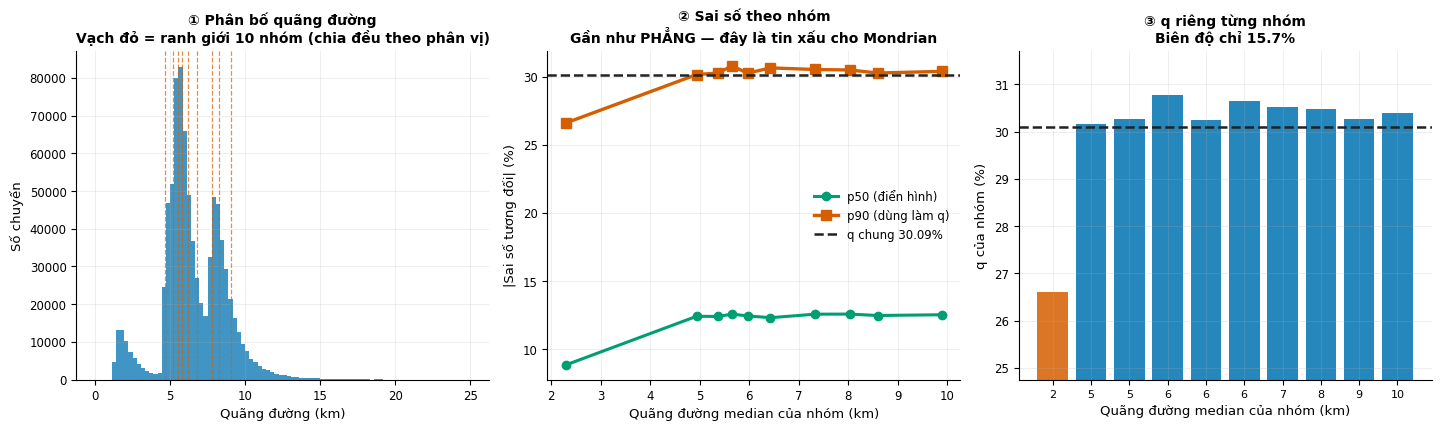

 nhom   km median   n (calib)      p50   q = p90
--------------------------------------------------
    0        2.31      61,664    8.87%    26.61%
    1        4.94      61,608   12.43%    30.15%
    2        5.37      61,588   12.41%    30.26%
    3        5.65      61,656   12.58%    30.78%
    4        5.97      61,444   12.46%    30.25%
    5        6.43      61,708   12.32%    30.64%
    6        7.33      61,496   12.58%    30.52%
    7        8.03      61,636   12.59%    30.49%
    8        8.60      61,556   12.48%    30.26%
    9        9.89      61,552   12.54%    30.38%

q thap nhat 26.61% (nhom 0) | cao nhat 30.78% (nhom 3) | bien do 15.7%


In [21]:
# ═════════ HINH MD1 — sai so theo quang duong ═════════
N_NHOM = 10
canh = np.quantile(cal.quote_distance, np.linspace(0, 1, N_NHOM + 1))
canh[0], canh[-1] = -np.inf, np.inf

for d in (cal, tes):
    d["nhom"] = pd.cut(d.quote_distance, bins=canh, labels=False, include_lowest=True)

g = cal.groupby("nhom").agg(km=("quote_distance", "median"), n=("e", "size"),
                            p50=("e", lambda s: s.quantile(.50)),
                            p90=("e", lambda s: s.quantile(.90)),
                            mae=("e", "mean"))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].hist(tes.quote_distance, bins=90, range=(0, 25), color=BLUE, alpha=.75, lw=0)
for c in canh[1:-1]:
    ax[0].axvline(c, color=RED, lw=.9, ls="--", alpha=.7)
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title(f"① Phân bố quãng đường\nVạch đỏ = ranh giới {N_NHOM} nhóm (chia đều theo phân vị)",
                fontweight="bold", fontsize=10)

ax[1].plot(g.km, g.p50*100, marker="o", lw=2.2, ms=6, color=GREEN, label="p50 (điển hình)")
ax[1].plot(g.km, g.p90*100, marker="s", lw=2.4, ms=7, color=RED, label="p90 (dùng làm q)")
ax[1].axhline(Q_CHUNG*100, color=INK, lw=1.8, ls="--", label=f"q chung {Q_CHUNG:.2%}")
ax[1].set_xlabel("Quãng đường median của nhóm (km)")
ax[1].set_ylabel("|Sai số tương đối| (%)")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Sai số theo nhóm\nGần như PHẲNG — đây là tin xấu cho Mondrian",
                fontweight="bold", fontsize=10)

bd = (g.p90.max()/g.p90.min() - 1)*100
b = ax[2].bar(range(len(g)), g.p90*100, color=[RED if i == g.p90.idxmin() else BLUE
                                               for i in g.index], alpha=.85)
ax[2].axhline(Q_CHUNG*100, color=INK, lw=1.8, ls="--")
ax[2].set_ylim(min(g.p90*100)*0.93, max(g.p90*100)*1.03)
ax[2].set_xticks(range(len(g)))
ax[2].set_xticklabels([f"{k:.0f}" for k in g.km], fontsize=8)
ax[2].set_xlabel("Quãng đường median của nhóm (km)"); ax[2].set_ylabel("q của nhóm (%)")
ax[2].set_title(f"③ q riêng từng nhóm\nBiên độ chỉ {bd:.1f}%", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD1_sai_so_theo_km.png"); plt.show()

print(f"{'nhom':>5s} {'km median':>11s} {'n (calib)':>11s} {'p50':>8s} {'q = p90':>9s}")
print("-" * 50)
for i, r in g.iterrows():
    print(f"{i:5d} {r.km:11.2f} {int(r.n):11,d} {r.p50:8.2%} {r.p90:9.2%}")
print()
print(f"q thap nhat {g.p90.min():.2%} (nhom {g.p90.idxmin()}) | "
      f"cao nhat {g.p90.max():.2%} (nhom {g.p90.idxmax()}) | bien do {bd:.1f}%")

## 2. Chênh lệch đó là tín hiệu thật hay nhiễu lấy mẫu?

Biên độ vài phần trăm nhìn thì nhỏ, nhưng **có thật sự tồn tại không**? Mỗi nhóm chỉ ước lượng `q`
từ một phần dữ liệu, nên bản thân `q` cũng có sai số.

Dùng **bootstrap**: lấy mẫu lại có hoàn lại 200 lần trong mỗi nhóm, xem `q` dao động bao nhiêu.
Nếu khoảng tin cậy của các nhóm **chồng lấn hết** lên nhau ⇒ chênh lệch là nhiễu, chia nhóm vô nghĩa.

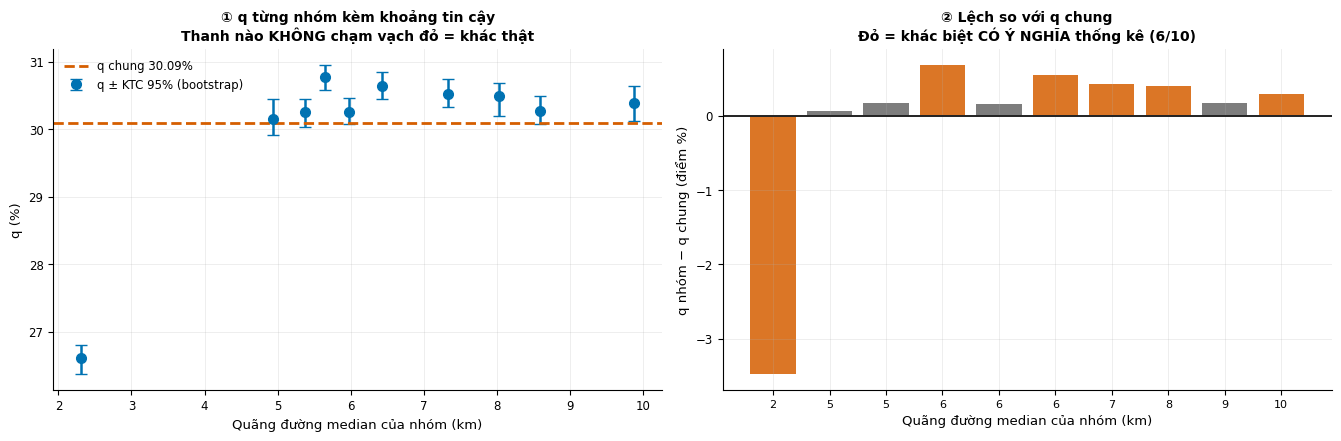

 nhom      km        q            KTC 95%  khac q chung?
----------------------------------------------------------
    0    2.31   26.61%  [26.37%, 26.80%]  CO  <<<
    1    4.94   30.15%  [29.92%, 30.45%]  khong
    2    5.37   30.26%  [30.03%, 30.45%]  khong
    3    5.65   30.78%  [30.58%, 30.96%]  CO  <<<
    4    5.97   30.25%  [30.08%, 30.46%]  khong
    5    6.43   30.64%  [30.45%, 30.85%]  CO  <<<
    6    7.33   30.52%  [30.34%, 30.74%]  CO  <<<
    7    8.03   30.49%  [30.20%, 30.68%]  CO  <<<
    8    8.60   30.26%  [30.08%, 30.49%]  khong
    9    9.89   30.38%  [30.13%, 30.64%]  CO  <<<

=> 6/10 nhom co q khac q chung mot cach CO Y NGHIA THONG KE.
   (n moi nhom ~62.000 nen uoc luong q rat chinh xac — KTC rat hep)


In [22]:
# ═════════ HINH MD2 — bootstrap ═════════
rng = np.random.default_rng(42)
B = 200
boot = {}
for i in sorted(cal.nhom.unique()):
    arr = cal.loc[cal.nhom == i, "e"].values
    qs = [np.quantile(rng.choice(arr, size=len(arr), replace=True), MUC) for _ in range(B)]
    boot[i] = np.array(qs)

lo = np.array([np.percentile(boot[i], 2.5) for i in sorted(boot)])
hi = np.array([np.percentile(boot[i], 97.5) for i in sorted(boot)])
mid = g.p90.values

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.5))

ax[0].errorbar(g.km, mid*100, yerr=[(mid-lo)*100, (hi-mid)*100], fmt="o",
               color=BLUE, ms=7, capsize=4, lw=1.8, label="q ± KTC 95% (bootstrap)")
ax[0].axhline(Q_CHUNG*100, color=RED, lw=2, ls="--", label=f"q chung {Q_CHUNG:.2%}")
ax[0].set_xlabel("Quãng đường median của nhóm (km)"); ax[0].set_ylabel("q (%)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① q từng nhóm kèm khoảng tin cậy\nThanh nào KHÔNG chạm vạch đỏ = khác thật",
                fontweight="bold", fontsize=10)

khac = ~((lo <= Q_CHUNG) & (hi >= Q_CHUNG))
b = ax[1].bar(range(len(mid)), (mid - Q_CHUNG)*100,
              color=[RED if k else MUT for k in khac], alpha=.85)
ax[1].axhline(0, color=INK, lw=1.4)
ax[1].set_xticks(range(len(mid)))
ax[1].set_xticklabels([f"{k:.0f}" for k in g.km], fontsize=8)
ax[1].set_xlabel("Quãng đường median của nhóm (km)")
ax[1].set_ylabel("q nhóm − q chung (điểm %)")
ax[1].set_title(f"② Lệch so với q chung\nĐỏ = khác biệt CÓ Ý NGHĨA thống kê ({khac.sum()}/{len(khac)})",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD2_bootstrap_q.png"); plt.show()

print(f"{'nhom':>5s} {'km':>7s} {'q':>8s} {'KTC 95%':>18s}  khac q chung?")
print("-" * 58)
for j, i in enumerate(sorted(boot)):
    dau = "CO  <<<" if khac[j] else "khong"
    print(f"{i:5d} {g.km.iloc[j]:7.2f} {mid[j]:8.2%}  [{lo[j]:.2%}, {hi[j]:.2%}]  {dau}")
print()
print(f"=> {khac.sum()}/{len(khac)} nhom co q khac q chung mot cach CO Y NGHIA THONG KE.")
print("   (n moi nhom ~62.000 nen uoc luong q rat chinh xac — KTC rat hep)")

## 3. Mondrian đổi coverage và độ rộng thế nào

Giờ áp `q` riêng từng nhóm lên tập test và so trực tiếp với cách dùng `q` chung.

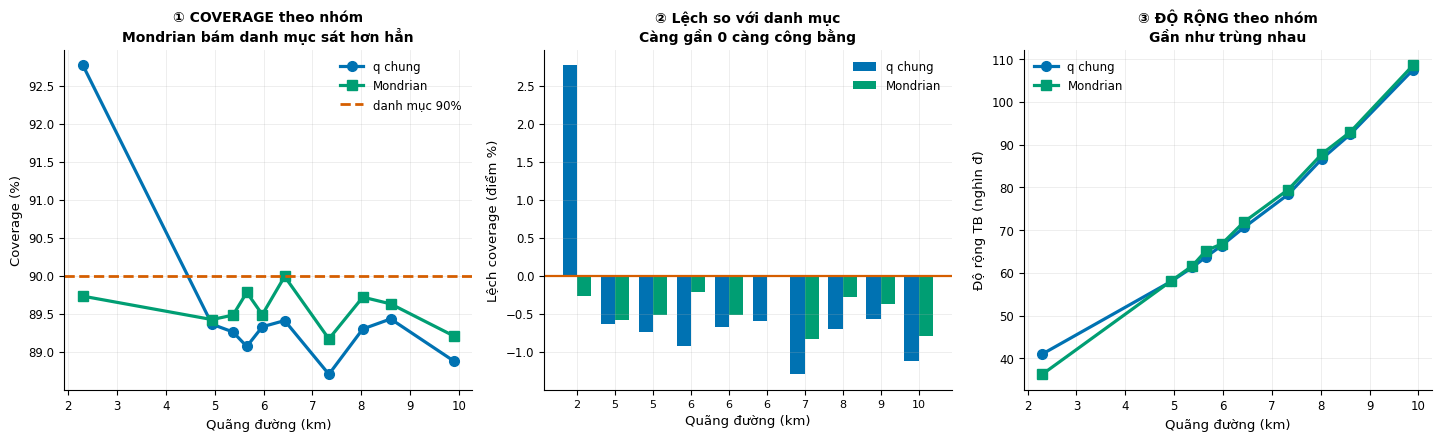

                                 q chung      Mondrian        doi
Coverage tong the                89.55%        89.56%
Lech coverage TOI DA             2.77 d        0.83 d       -70%
Lech coverage TRUNG BINH         1.00 d        0.44 d       -56%
Do rong TB                      72,630d       72,895d     +0.36%


In [23]:
# ═════════ HINH MD3 — coverage & do rong ═════════
q_nhom = cal.groupby("nhom").e.quantile(MUC)

t = tes.copy()
t["q_mon"] = t.nhom.map(q_nhom).astype(float)
t["trong_chung"] = ((t.gia_that >= t.hybrid_pred*(1-Q_CHUNG)) &
                    (t.gia_that <= t.hybrid_pred*(1+Q_CHUNG)))
t["trong_mon"] = ((t.gia_that >= t.hybrid_pred*(1-t.q_mon)) &
                  (t.gia_that <= t.hybrid_pred*(1+t.q_mon)))
t["rong_chung"] = t.hybrid_pred * 2 * Q_CHUNG
t["rong_mon"] = t.hybrid_pred * 2 * t.q_mon

gt = t.groupby("nhom").agg(km=("quote_distance", "median"),
                           c_chung=("trong_chung", "mean"), c_mon=("trong_mon", "mean"),
                           r_chung=("rong_chung", "mean"), r_mon=("rong_mon", "mean"))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.5))

ax[0].plot(gt.km, gt.c_chung*100, marker="o", lw=2.3, ms=7, color=BLUE, label="q chung")
ax[0].plot(gt.km, gt.c_mon*100, marker="s", lw=2.3, ms=7, color=GREEN, label="Mondrian")
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--", label="danh mục 90%")
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Coverage (%)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① COVERAGE theo nhóm\nMondrian bám danh mục sát hơn hẳn",
                fontweight="bold", fontsize=10)

ax[1].bar(np.arange(len(gt))-0.19, (gt.c_chung*100-MUC*100), 0.38, color=BLUE, label="q chung")
ax[1].bar(np.arange(len(gt))+0.19, (gt.c_mon*100-MUC*100), 0.38, color=GREEN, label="Mondrian")
ax[1].axhline(0, color=RED, lw=1.6)
ax[1].set_xticks(range(len(gt))); ax[1].set_xticklabels([f"{k:.0f}" for k in gt.km], fontsize=8)
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("Lệch coverage (điểm %)")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Lệch so với danh mục\nCàng gần 0 càng công bằng", fontweight="bold", fontsize=10)

ax[2].plot(gt.km, gt.r_chung/1000, marker="o", lw=2.3, ms=7, color=BLUE, label="q chung")
ax[2].plot(gt.km, gt.r_mon/1000, marker="s", lw=2.3, ms=7, color=GREEN, label="Mondrian")
ax[2].set_xlabel("Quãng đường (km)"); ax[2].set_ylabel("Độ rộng TB (nghìn đ)")
ax[2].legend(frameon=False, fontsize=8.5)
ax[2].set_title("③ ĐỘ RỘNG theo nhóm\nGần như trùng nhau", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD3_mondrian_ket_qua.png"); plt.show()

l_chung = abs(gt.c_chung*100 - MUC*100)
l_mon = abs(gt.c_mon*100 - MUC*100)
print("=" * 68)
print(f"{'':26s} {'q chung':>13s} {'Mondrian':>13s} {'doi':>10s}")
print("=" * 68)
print(f"{'Coverage tong the':26s} {t.trong_chung.mean():12.2%} {t.trong_mon.mean():13.2%}")
print(f"{'Lech coverage TOI DA':26s} {l_chung.max():10.2f} d {l_mon.max():11.2f} d "
      f"{(l_mon.max()/l_chung.max()-1)*100:+9.0f}%")
print(f"{'Lech coverage TRUNG BINH':26s} {l_chung.mean():10.2f} d {l_mon.mean():11.2f} d "
      f"{(l_mon.mean()/l_chung.mean()-1)*100:+9.0f}%")
print(f"{'Do rong TB':26s} {t.rong_chung.mean():11,.0f}d {t.rong_mon.mean():12,.0f}d "
      f"{(t.rong_mon.mean()/t.rong_chung.mean()-1)*100:+9.2f}%")

## 4. Chia bao nhiêu nhóm là tối ưu?

Đánh đổi kinh điển:

- **Ít nhóm** → mỗi nhóm nhiều dữ liệu, `q` ước lượng chính xác, nhưng **thô** (không bắt được khác biệt)
- **Nhiều nhóm** → bắt được khác biệt tinh, nhưng `q` mỗi nhóm ước lượng từ ít dữ liệu ⇒ **nhiễu**,
  và coverage trên test có thể **tệ đi**

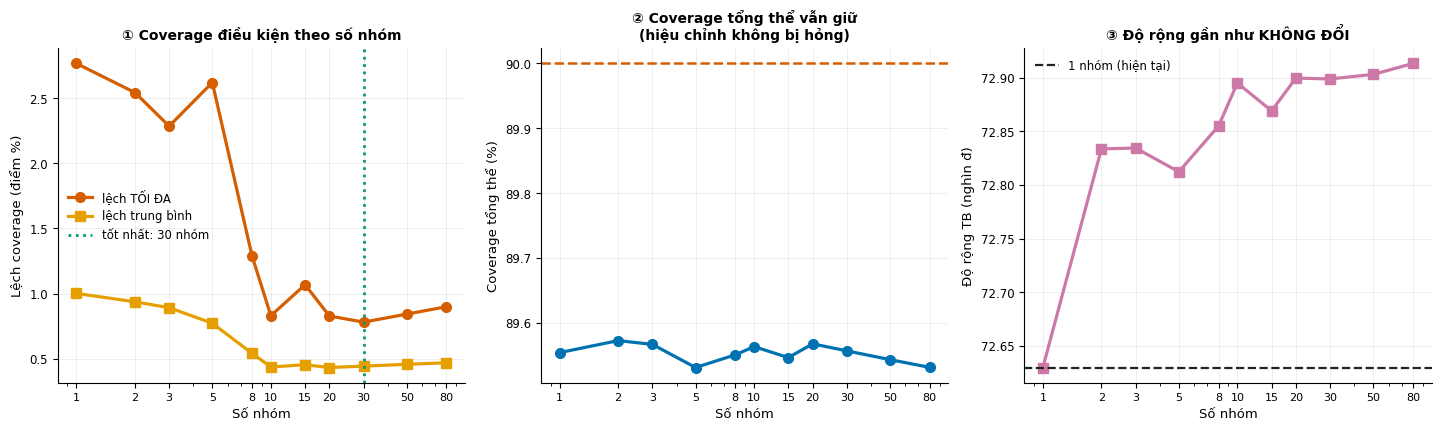

,n_nhom,n_calib_moi_nhom,coverage,lech_max,lech_tb,rong_tb
0,1,615908,89.55,2.77,1.00,72630.0
1,2,307954,89.57,2.54,0.94,72834.0
2,3,205302,89.57,2.28,0.89,72834.0
3,5,123181,89.53,2.62,0.77,72812.0
4,8,76988,89.55,1.29,0.54,72855.0
5,10,61590,89.56,0.83,0.44,72895.0
6,15,41060,89.55,1.07,0.45,72869.0
7,20,30795,89.57,0.83,0.43,72899.0
8,30,20530,89.56,0.78,0.44,72899.0
9,50,12318,89.54,0.84,0.46,72903.0



So nhom cho lech TOI DA nho nhat: 30


In [24]:
# ═════════ HINH MD4 — quet so nhom ═════════
SO_NHOM = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 80]
kq = []
for n in SO_NHOM:
    if n == 1:
        qc_ = pd.Series({0: Q_CHUNG}); c_cal = pd.Series(0, index=cal.index)
        c_tes = pd.Series(0, index=tes.index)
    else:
        bins = np.quantile(cal.quote_distance, np.linspace(0, 1, n + 1))
        bins[0], bins[-1] = -np.inf, np.inf
        bins = np.unique(bins)
        c_cal = pd.cut(cal.quote_distance, bins=bins, labels=False, include_lowest=True)
        c_tes = pd.cut(tes.quote_distance, bins=bins, labels=False, include_lowest=True)
        qc_ = cal.groupby(c_cal).e.quantile(MUC)
    qq = c_tes.map(qc_).astype(float).fillna(Q_CHUNG)
    trong = ((tes.gia_that >= tes.hybrid_pred*(1-qq)) &
             (tes.gia_that <= tes.hybrid_pred*(1+qq)))
    # danh gia coverage dieu kien tren luoi CO DINH 10 nhom (de so sanh cong bang)
    lech = abs(trong.groupby(tes.nhom).mean()*100 - MUC*100)
    kq.append({"n_nhom": n, "n_calib_moi_nhom": int(len(cal)/n),
               "coverage": trong.mean(), "lech_max": lech.max(), "lech_tb": lech.mean(),
               "rong_tb": (tes.hybrid_pred*2*qq).mean()})
K = pd.DataFrame(kq)

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].plot(K.n_nhom, K.lech_max, marker="o", lw=2.3, ms=7, color=RED, label="lệch TỐI ĐA")
ax[0].plot(K.n_nhom, K.lech_tb, marker="s", lw=2.3, ms=7, color=ORANGE, label="lệch trung bình")
k_tot = K.loc[K.lech_max.idxmin(), "n_nhom"]
ax[0].axvline(k_tot, color=GREEN, lw=2, ls=":", label=f"tốt nhất: {k_tot} nhóm")
ax[0].set_xscale("log"); ax[0].set_xticks(SO_NHOM)
ax[0].set_xticklabels(SO_NHOM, fontsize=8)
ax[0].set_xlabel("Số nhóm"); ax[0].set_ylabel("Lệch coverage (điểm %)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Coverage điều kiện theo số nhóm", fontweight="bold", fontsize=10)

ax[1].plot(K.n_nhom, K.coverage*100, marker="o", lw=2.3, ms=7, color=BLUE)
ax[1].axhline(MUC*100, color=RED, lw=1.8, ls="--")
ax[1].set_xscale("log"); ax[1].set_xticks(SO_NHOM); ax[1].set_xticklabels(SO_NHOM, fontsize=8)
ax[1].set_xlabel("Số nhóm"); ax[1].set_ylabel("Coverage tổng thể (%)")
ax[1].set_title("② Coverage tổng thể vẫn giữ\n(hiệu chỉnh không bị hỏng)",
                fontweight="bold", fontsize=10)

ax[2].plot(K.n_nhom, K.rong_tb/1000, marker="s", lw=2.3, ms=7, color=PURPLE)
ax[2].axhline(K.rong_tb.iloc[0]/1000, color=INK, lw=1.6, ls="--", label="1 nhóm (hiện tại)")
ax[2].set_xscale("log"); ax[2].set_xticks(SO_NHOM); ax[2].set_xticklabels(SO_NHOM, fontsize=8)
ax[2].set_xlabel("Số nhóm"); ax[2].set_ylabel("Độ rộng TB (nghìn đ)")
ax[2].legend(frameon=False, fontsize=8.5)
ax[2].set_title("③ Độ rộng gần như KHÔNG ĐỔI", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD4_so_nhom_toi_uu.png"); plt.show()

display(K.assign(coverage=lambda x: (x.coverage*100).round(2),
                 lech_max=lambda x: x.lech_max.round(2),
                 lech_tb=lambda x: x.lech_tb.round(2),
                 rong_tb=lambda x: x.rong_tb.round(0)))
print(f"\nSo nhom cho lech TOI DA nho nhat: {k_tot}")

## 5. So với CQR — cái nào xử lý chiều quãng đường tốt hơn

CQR cũng cải thiện coverage điều kiện theo quãng đường (đã đo ở `00_TONG_QUAN`: 0,95 điểm so
với 2,04 của conformal chung). Vậy Mondrian và CQR — nên chọn cái nào?

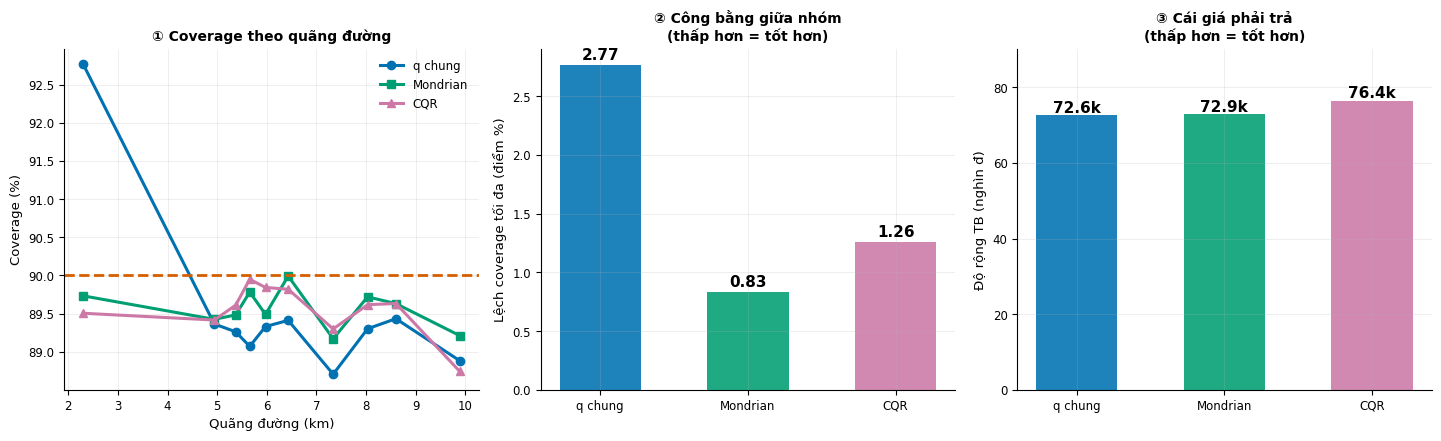

Phương pháp Coverage tổng  Lệch tối đa (điểm) Độ rộng TB (đ)
    q chung        89.55%                2.77         72,630
   Mondrian        89.56%                0.83         72,895
        CQR        89.54%                1.26         76,449


In [25]:
# ═════════ HINH MD5 — Mondrian vs CQR ═════════
E = np.maximum(qcal.q05 - qcal.gia_that, qcal.gia_that - qcal.q95).values
k_ = min(int(np.ceil((len(qcal)+1)*MUC)), len(qcal))
q_cqr = np.sort(E)[k_-1]

t["trong_cqr"] = ((qtes.gia_that.values >= (qtes.q05 - q_cqr).values) &
                  (qtes.gia_that.values <= (qtes.q95 + q_cqr).values))
t["rong_cqr"] = ((qtes.q95 + q_cqr) - (qtes.q05 - q_cqr)).values

gg = t.groupby("nhom").agg(km=("quote_distance", "median"),
                           chung=("trong_chung", "mean"), mon=("trong_mon", "mean"),
                           cqr=("trong_cqr", "mean"),
                           r_chung=("rong_chung", "mean"), r_mon=("rong_mon", "mean"),
                           r_cqr=("rong_cqr", "mean"))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.5))

for col, ten, col_m, mk in [("chung", "q chung", BLUE, "o"), ("mon", "Mondrian", GREEN, "s"),
                            ("cqr", "CQR", PURPLE, "^")]:
    ax[0].plot(gg.km, gg[col]*100, marker=mk, lw=2.2, ms=6, color=col_m, label=ten)
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--")
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Coverage (%)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Coverage theo quãng đường", fontweight="bold", fontsize=10)

ten3 = ["q chung", "Mondrian", "CQR"]
lech3 = [abs(gg.chung*100-MUC*100).max(), abs(gg.mon*100-MUC*100).max(),
         abs(gg.cqr*100-MUC*100).max()]
rong3 = [t.rong_chung.mean()/1000, t.rong_mon.mean()/1000, t.rong_cqr.mean()/1000]
b = ax[1].bar(ten3, lech3, color=[BLUE, GREEN, PURPLE], alpha=.88, width=.55)
for bb, v in zip(b, lech3):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+.05, f"{v:.2f}", ha="center",
               fontsize=11, fontweight="bold")
ax[1].set_ylabel("Lệch coverage tối đa (điểm %)")
ax[1].set_title("② Công bằng giữa nhóm\n(thấp hơn = tốt hơn)", fontweight="bold", fontsize=10)

b2 = ax[2].bar(ten3, rong3, color=[BLUE, GREEN, PURPLE], alpha=.88, width=.55)
for bb, v in zip(b2, rong3):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+.8, f"{v:.1f}k", ha="center",
               fontsize=11, fontweight="bold")
ax[2].set_ylabel("Độ rộng TB (nghìn đ)"); ax[2].set_ylim(0, max(rong3)*1.18)
ax[2].set_title("③ Cái giá phải trả\n(thấp hơn = tốt hơn)", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD5_mondrian_vs_cqr.png"); plt.show()

print(pd.DataFrame({
    "Phương pháp": ten3,
    "Coverage tổng": [f"{t.trong_chung.mean():.2%}", f"{t.trong_mon.mean():.2%}",
                      f"{t.trong_cqr.mean():.2%}"],
    "Lệch tối đa (điểm)": [round(v, 2) for v in lech3],
    "Độ rộng TB (đ)": [f"{v*1000:,.0f}" for v in rong3],
}).to_string(index=False))

## 6. Kết luận — có đáng dùng không

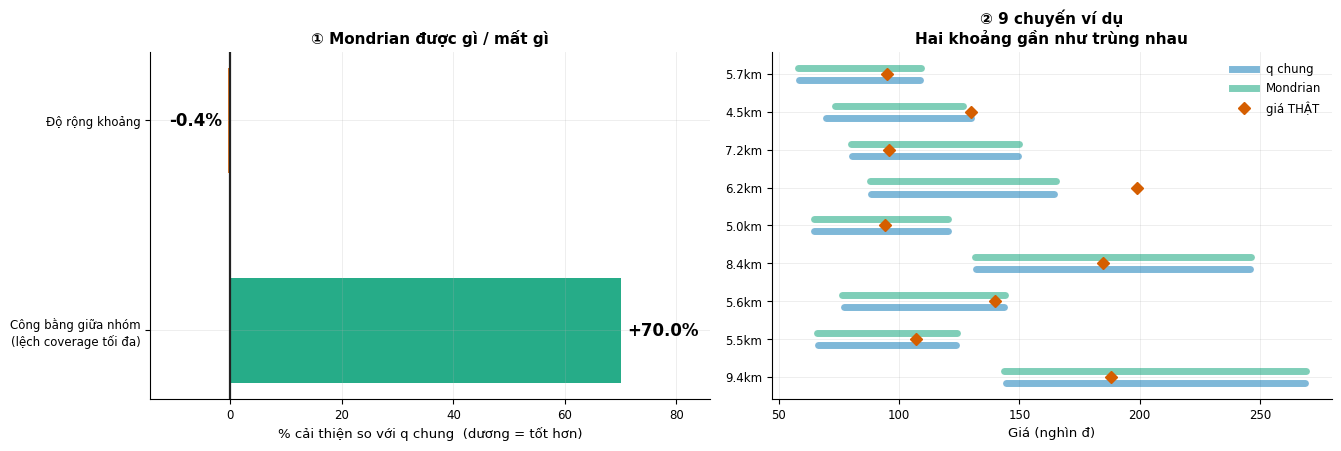

╔══════════════════════════════════════════════════════════════════════╗
║           MONDRIAN THEO QUANG DUONG — CO DANG DUNG KHONG?            ║
╚══════════════════════════════════════════════════════════════════════╝

  DUOC:  cong bang giua nhom tot hon 70%
         (lech coverage toi da 2.77 -> 0.83 diem)

  MAT:   do rong TB thay doi +0.36%
         (72,630d -> 72,895d)

  CHI PHI TRIEN KHAI: luu them 10 con so q thay vi 1.

────────────────────────────────────────────────────────────────────────
  => NEN DUNG. Cai thien cong bang ro ret, gan nhu khong ton them do rong.
────────────────────────────────────────────────────────────────────────


In [26]:
# ═════════ HINH MD6 — tong ket ═════════
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))

cai_thien = (1 - l_mon.max()/l_chung.max())*100
gia_phai_tra = (t.rong_mon.mean()/t.rong_chung.mean() - 1)*100

b = ax[0].barh(["Công bằng giữa nhóm\n(lệch coverage tối đa)", "Độ rộng khoảng"],
               [cai_thien, -gia_phai_tra],
               color=[GREEN if cai_thien > 0 else RED,
                      GREEN if gia_phai_tra < 0 else RED], alpha=.85, height=.5)
ax[0].axvline(0, color=INK, lw=1.6)
for bb, v in zip(b, [cai_thien, -gia_phai_tra]):
    ax[0].text(v + (1.2 if v >= 0 else -1.2), bb.get_y()+bb.get_height()/2,
               f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right",
               fontsize=12, fontweight="bold")
ax[0].set_xlabel("% cải thiện so với q chung  (dương = tốt hơn)")
ax[0].set_xlim(min(-gia_phai_tra, 0)-14, cai_thien+16)
ax[0].set_title("① Mondrian được gì / mất gì", fontweight="bold", fontsize=11)

ss = t.sample(9, random_state=7).reset_index(drop=True)
yy = np.arange(len(ss))
for i, r in ss.iterrows():
    ax[1].plot([r.hybrid_pred*(1-Q_CHUNG)/1000, r.hybrid_pred*(1+Q_CHUNG)/1000],
               [i-0.16, i-0.16], lw=5, color=BLUE, alpha=.5, solid_capstyle="round")
    ax[1].plot([r.hybrid_pred*(1-r.q_mon)/1000, r.hybrid_pred*(1+r.q_mon)/1000],
               [i+0.16, i+0.16], lw=5, color=GREEN, alpha=.5, solid_capstyle="round")
    ax[1].plot(r.gia_that/1000, i, "D", color=RED, ms=6, zorder=5)
ax[1].plot([], [], lw=5, color=BLUE, alpha=.5, label="q chung")
ax[1].plot([], [], lw=5, color=GREEN, alpha=.5, label="Mondrian")
ax[1].plot([], [], "D", color=RED, ms=6, label="giá THẬT")
ax[1].set_yticks(yy)
ax[1].set_yticklabels([f"{r.quote_distance:.1f}km" for _, r in ss.iterrows()], fontsize=8.5)
ax[1].set_xlabel("Giá (nghìn đ)"); ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② 9 chuyến ví dụ\nHai khoảng gần như trùng nhau", fontweight="bold", fontsize=11)

plt.tight_layout(); plt.savefig(HINH / "MD6_tong_ket.png"); plt.show()

print("╔" + "═"*70 + "╗")
print("║" + " MONDRIAN THEO QUANG DUONG — CO DANG DUNG KHONG? ".center(70) + "║")
print("╚" + "═"*70 + "╝")
print()
print(f"  DUOC:  cong bang giua nhom tot hon {cai_thien:.0f}%")
print(f"         (lech coverage toi da {l_chung.max():.2f} -> {l_mon.max():.2f} diem)")
print()
print(f"  MAT:   do rong TB thay doi {gia_phai_tra:+.2f}%")
print(f"         ({t.rong_chung.mean():,.0f}d -> {t.rong_mon.mean():,.0f}d)")
print()
print(f"  CHI PHI TRIEN KHAI: luu them {N_NHOM} con so q thay vi 1.")
print()
print("─" * 72)
if cai_thien > 20 and abs(gia_phai_tra) < 2:
    print("  => NEN DUNG. Cai thien cong bang ro ret, gan nhu khong ton them do rong.")
elif cai_thien > 0:
    print("  => CO THE DUNG. Loi ich vua phai.")
else:
    print("  => KHONG NEN. Khong cai thien duoc gi.")
print("─" * 72)

---

# 4. Phân rã theo band giá — nơi vấn đề lớn nhất

Cùng kỹ thuật phần 3 nhưng chia nhóm theo **giá dự đoán**. Đây là chiều mà mentor chỉ đích danh, và cũng là nơi Conformal chuẩn hoá hỏng nặng nhất.

In [27]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC = 0.90
CANH = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
MAU_BAND = [PURPLE, BLUE, GREEN, "#8A9A00", ORANGE, RED]

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
sai_cal = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values
q90 = np.quantile(sai_cal, MUC)

t = ut[["hybrid_pred", "gia_that", "gio_vn", "quote_distance"]].copy()
t["band"] = pd.cut(t.hybrid_pred, CANH, labels=TEN, right=False)
uc = uc.copy()
uc["band"] = pd.cut(uc.hybrid_pred, CANH, labels=TEN, right=False)
uc["e"] = (uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred

print(f"Calibration {len(uc):,} | Test {len(t):,}")
print(f"q chung ca bo = ±{q90:.2%}\n")
print("So chuyen tung band (test):")
for b, n in t.band.value_counts().reindex(TEN).items():
    print(f"  {b:>10s} {n:>9,}  ({n/len(t):>5.1%})")

Calibration 615,908 | Test 864,360
q chung ca bo = ±30.09%

So chuyen tung band (test):
        <50k    10,821  ( 1.3%)
     50–100k   264,201  (30.6%)
    100–150k   409,883  (47.4%)
    150–200k   149,324  (17.3%)
    200–300k    28,875  ( 3.3%)
       >300k     1,256  ( 0.1%)


## 1. Bảng đầy đủ theo band giá

Đây là bảng mentor đề nghị điền. Dùng **Conformal chuẩn hoá, mức tin cậy 90%**.

In [28]:
def dung_khoang(df, q_ser_or_val):
    d = df.copy()
    q = (d.band.map(q_ser_or_val).astype(float)
         if isinstance(q_ser_or_val, (pd.Series, dict)) else float(q_ser_or_val))
    d["q"] = q
    d["lo"] = d.hybrid_pred * (1 - q)
    d["hi"] = d.hybrid_pred * (1 + q)
    d["rong"] = d.hi - d.lo
    d["rel"] = d.rong / d.hybrid_pred
    d["trong"] = (d.gia_that >= d.lo) & (d.gia_that <= d.hi)
    d["tren"] = d.gia_that > d.hi
    d["duoi"] = d.gia_that < d.lo
    return d


T = dung_khoang(t, q90)
g = T.groupby("band", observed=True).agg(
    n=("gia_that", "size"), cvg=("trong", "mean"),
    w_med=("rong", "median"), w_p90=("rong", lambda s: s.quantile(.90)),
    rel_med=("rel", "median"), tren=("tren", "mean"), duoi=("duoi", "mean")).reindex(TEN)

# Sai so lay mau cua coverage — de biet lech co that khong
g["se"] = np.sqrt(g.cvg * (1 - g.cvg) / g.n)

B = pd.DataFrame({
    "Predicted-price band": TEN,
    "Number of quotes": [f"{v:,}" for v in g.n],
    "Actual coverage": [f"{v:.2%}" for v in g.cvg],
    "Median full width": [f"{v:,.0f}đ" for v in g.w_med],
    "P90 full width": [f"{v:,.0f}đ" for v in g.w_p90],
    "Median relative width": [f"{v:.1%}" for v in g.rel_med],
    "Upper miss": [f"{v:.2%}" for v in g.tren],
    "Lower miss": [f"{v:.2%}" for v in g.duoi],
})
display(B.style.hide(axis="index"))

print(f"{'TOAN BO':22s} {len(T):>9,}  {T.trong.mean():.2%}  "
      f"{T.rong.median():>9,.0f}d  {T.rong.quantile(.9):>9,.0f}d  "
      f"{T.rel.median():.1%}  {T.tren.mean():.2%}  {T.duoi.mean():.2%}")
print()
print("LECH COVERAGE CO THAT KHONG? (kiem tra bang sai so lay mau)")
print(f"  {'Band':>10s} {'coverage':>10s} {'±1.96·SE':>11s} {'lech vs 90%':>13s}  ket luan")
print("  " + "-" * 62)
for b in TEN:
    r = g.loc[b]
    bien = 1.96 * r.se * 100
    lech = (r.cvg - MUC) * 100
    kl = "THAT" if abs(lech) > bien else "trong nhieu"
    print(f"  {b:>10s} {r.cvg:>10.2%} {bien:>10.2f}p {lech:>+12.2f}p  {kl}")

Predicted-price band,Number of quotes,Actual coverage,Median full width,P90 full width,Median relative width,Upper miss,Lower miss
<50k,"10,821",92.40%,"26,756đ","29,597đ",60.2%,7.07%,0.53%
50–100k,"264,201",90.31%,"50,904đ","58,572đ",60.2%,7.26%,2.43%
100–150k,"409,883",89.15%,"72,505đ","85,943đ",60.2%,8.09%,2.76%
150–200k,"149,324",89.27%,"100,346đ","114,052đ",60.2%,8.03%,2.69%
200–300k,"28,875",89.09%,"130,627đ","154,653đ",60.2%,8.44%,2.47%
>300k,"1,256",82.72%,"196,603đ","226,886đ",60.2%,11.78%,5.49%


TOAN BO                  864,360  89.55%     69,408d    103,631d  60.2%  7.83%  2.62%

LECH COVERAGE CO THAT KHONG? (kiem tra bang sai so lay mau)
        Band   coverage    ±1.96·SE   lech vs 90%  ket luan
  --------------------------------------------------------------
        <50k     92.40%       0.50p        +2.40p  THAT
     50–100k     90.31%       0.11p        +0.31p  THAT
    100–150k     89.15%       0.10p        -0.85p  THAT
    150–200k     89.27%       0.16p        -0.73p  THAT
    200–300k     89.09%       0.36p        -0.91p  THAT
       >300k     82.72%       2.09p        -7.28p  THAT


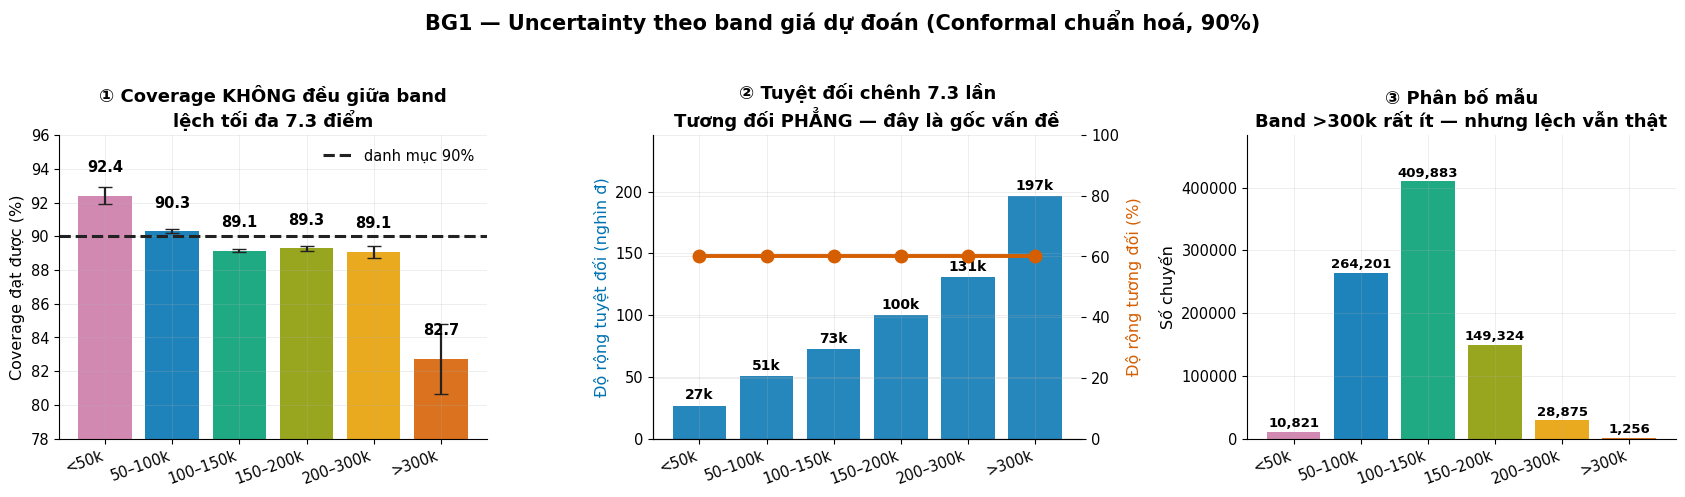

In [29]:
# ═════════ HINH BG1 — bang truc quan ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
x = np.arange(len(TEN))

# ① Coverage
b = ax[0].bar(x, g.cvg*100, color=MAU_BAND, alpha=.88)
ax[0].errorbar(x, g.cvg*100, yerr=1.96*g.se*100, fmt="none", ecolor=INK,
               capsize=5, lw=1.6)
ax[0].axhline(MUC*100, color=INK, lw=2.2, ls="--", label="danh mục 90%")
for i, v in enumerate(g.cvg*100):
    ax[0].text(i, v + 1.4, f"{v:.1f}", ha="center", fontsize=10.5, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=20, ha="right")
ax[0].set_ylabel("Coverage đạt được (%)"); ax[0].set_ylim(78, 96)
ax[0].legend(frameon=False)
ax[0].set_title("① Coverage KHÔNG đều giữa band\n"
                f"lệch tối đa {abs(g.cvg*100-90).max():.1f} điểm", fontweight="bold")

# ② Do rong tuyet doi vs tuong doi
ax2 = ax[1].twinx()
ax[1].bar(x, g.w_med/1000, color=BLUE, alpha=.85, label="độ rộng tuyệt đối")
ax2.plot(x, g.rel_med*100, marker="o", lw=2.8, ms=9, color=RED,
         label="độ rộng tương đối")
ax2.set_ylim(0, 100); ax2.set_ylabel("Độ rộng tương đối (%)", color=RED)
for i, v in enumerate(g.w_med/1000):
    ax[1].text(i, v + 5, f"{v:.0f}k", ha="center", fontsize=10, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN, rotation=20, ha="right")
ax[1].set_ylabel("Độ rộng tuyệt đối (nghìn đ)", color=BLUE)
ax[1].set_ylim(0, max(g.w_med/1000)*1.25)
ax[1].set_title(f"② Tuyệt đối chênh {g.w_med.max()/g.w_med.min():.1f} lần\n"
                "Tương đối PHẲNG — đây là gốc vấn đề", fontweight="bold")

# ③ So chuyen
b3 = ax[2].bar(x, g.n, color=MAU_BAND, alpha=.88)
for i, v in enumerate(g.n):
    ax[2].text(i, v + 8000, f"{v:,}", ha="center", fontsize=9.5, fontweight="bold")
ax[2].set_xticks(x); ax[2].set_xticklabels(TEN, rotation=20, ha="right")
ax[2].set_ylabel("Số chuyến"); ax[2].set_ylim(0, max(g.n)*1.18)
ax[2].set_title("③ Phân bố mẫu\nBand >300k rất ít — nhưng lệch vẫn thật",
                fontweight="bold")

fig.suptitle("BG1 — Uncertainty theo band giá dự đoán (Conformal chuẩn hoá, 90%)",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BG1_bang_theo_band.png"); plt.show()

## 2. Đường tin cậy từng band — chẩn đoán hiệu chỉnh

Bảng ở Phần 1 chỉ chụp **một mức tin cậy** (90%). Câu hỏi tiếp: ở **mọi mức** thì band nào lệch?

**Đường tin cậy** (reliability curve) quét mức danh mục từ 50% đến 99% và vẽ **coverage đạt được**
so với **mức danh mục**. Đây là chẩn đoán chuẩn cho UQ — tương tự vai trò của ROC trong bài toán
phân loại.

| Đọc thế nào | |
|---|---|
| Nằm **trên** đường chéo | Bao **thừa** — khoảng rộng hơn cần thiết, lãng phí nhưng an toàn |
| Nằm **dưới** đường chéo | **Hứa quá** — nguy hiểm, khoảng hẹp hơn thực tế cần |
| Bám sát đường chéo | Hiệu chỉnh tốt |

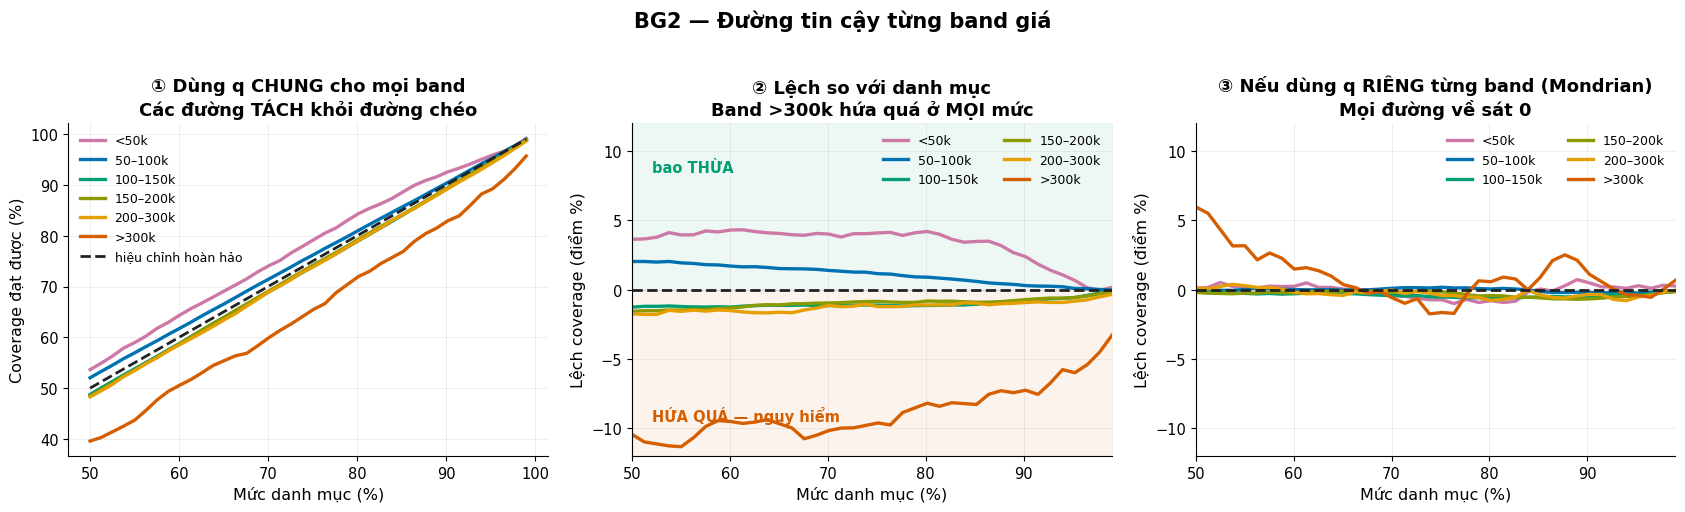

LECH COVERAGE TOI DA tren toan dai muc 50-99% (diem %):
        Band    q CHUNG    q RIENG   cai thien
  ------------------------------------------------
        <50k      4.32       0.99       77%
     50–100k      2.04       0.25       88%
    100–150k      1.25       0.59       53%
    150–200k      1.56       0.69       56%
    200–300k      1.78       0.79       55%
       >300k     11.32       5.97       47%


In [30]:
# ═════════ HINH BG2 — duong tin cay tung band ═════════
MUCS = np.linspace(.50, .99, 40)
REL = {}
for b in TEN:
    sub_c = uc[uc.band == b]
    sub_t = t[t.band == b]
    v = []
    for m in MUCS:
        qb = np.quantile(sub_c.e.values, m)          # q rieng cua band
        v.append(((sub_t.gia_that >= sub_t.hybrid_pred*(1-qb)) &
                  (sub_t.gia_that <= sub_t.hybrid_pred*(1+qb))).mean())
    REL[b] = np.array(v)

REL_CHUNG = {}
for b in TEN:
    sub_t = t[t.band == b]
    v = []
    for m in MUCS:
        qc_ = np.quantile(sai_cal, m)                # q CHUNG ca bo
        v.append(((sub_t.gia_that >= sub_t.hybrid_pred*(1-qc_)) &
                  (sub_t.gia_that <= sub_t.hybrid_pred*(1+qc_))).mean())
    REL_CHUNG[b] = np.array(v)

fig, ax = plt.subplots(1, 3, figsize=(17, 5.0))

for b, col in zip(TEN, MAU_BAND):
    ax[0].plot(MUCS*100, REL_CHUNG[b]*100, lw=2.4, color=col, label=b)
ax[0].plot([50, 99], [50, 99], color=INK, lw=2, ls="--", label="hiệu chỉnh hoàn hảo")
ax[0].set_xlabel("Mức danh mục (%)"); ax[0].set_ylabel("Coverage đạt được (%)")
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("① Dùng q CHUNG cho mọi band\nCác đường TÁCH khỏi đường chéo",
                fontweight="bold")

for b, col in zip(TEN, MAU_BAND):
    ax[1].plot(MUCS*100, (REL_CHUNG[b]-MUCS)*100, lw=2.4, color=col, label=b)
ax[1].axhline(0, color=INK, lw=2, ls="--")
ax[1].fill_between([50, 99], 0, 12, color=GREEN, alpha=.07)
ax[1].fill_between([50, 99], -12, 0, color=RED, alpha=.07)
ax[1].text(52, 8.5, "bao THỪA", fontsize=10.5, color=GREEN, fontweight="bold")
ax[1].text(52, -9.5, "HỨA QUÁ — nguy hiểm", fontsize=10.5, color=RED, fontweight="bold")
ax[1].set_xlabel("Mức danh mục (%)"); ax[1].set_ylabel("Lệch coverage (điểm %)")
ax[1].set_xlim(50, 99); ax[1].set_ylim(-12, 12)
ax[1].legend(frameon=False, fontsize=9, ncol=2)
ax[1].set_title("② Lệch so với danh mục\nBand >300k hứa quá ở MỌI mức",
                fontweight="bold")

for b, col in zip(TEN, MAU_BAND):
    ax[2].plot(MUCS*100, (REL[b]-MUCS)*100, lw=2.4, color=col, label=b)
ax[2].axhline(0, color=INK, lw=2, ls="--")
ax[2].set_xlabel("Mức danh mục (%)"); ax[2].set_ylabel("Lệch coverage (điểm %)")
ax[2].set_xlim(50, 99); ax[2].set_ylim(-12, 12)
ax[2].legend(frameon=False, fontsize=9, ncol=2)
ax[2].set_title("③ Nếu dùng q RIÊNG từng band (Mondrian)\nMọi đường về sát 0",
                fontweight="bold")

fig.suptitle("BG2 — Đường tin cậy từng band giá", fontweight="bold",
             fontsize=15, y=1.02)
plt.tight_layout(); plt.savefig(HINH / "BG2_duong_tin_cay.png"); plt.show()

print("LECH COVERAGE TOI DA tren toan dai muc 50-99% (diem %):")
print(f"  {'Band':>10s} {'q CHUNG':>10s} {'q RIENG':>10s}   cai thien")
print("  " + "-" * 48)
for b in TEN:
    a_ = np.abs(REL_CHUNG[b]-MUCS).max()*100
    c_ = np.abs(REL[b]-MUCS).max()*100
    print(f"  {b:>10s} {a_:>9.2f} {c_:>10.2f}   {(1-c_/a_)*100:>6.0f}%")

## 3. Trượt **lên** hay trượt **xuống**?

Coverage 89,55% chỉ nói *"10,5% rơi ra ngoài"* — không nói **rơi về phía nào**. Với bài toán định
giá thì hai chiều có hệ quả khác hẳn nhau.

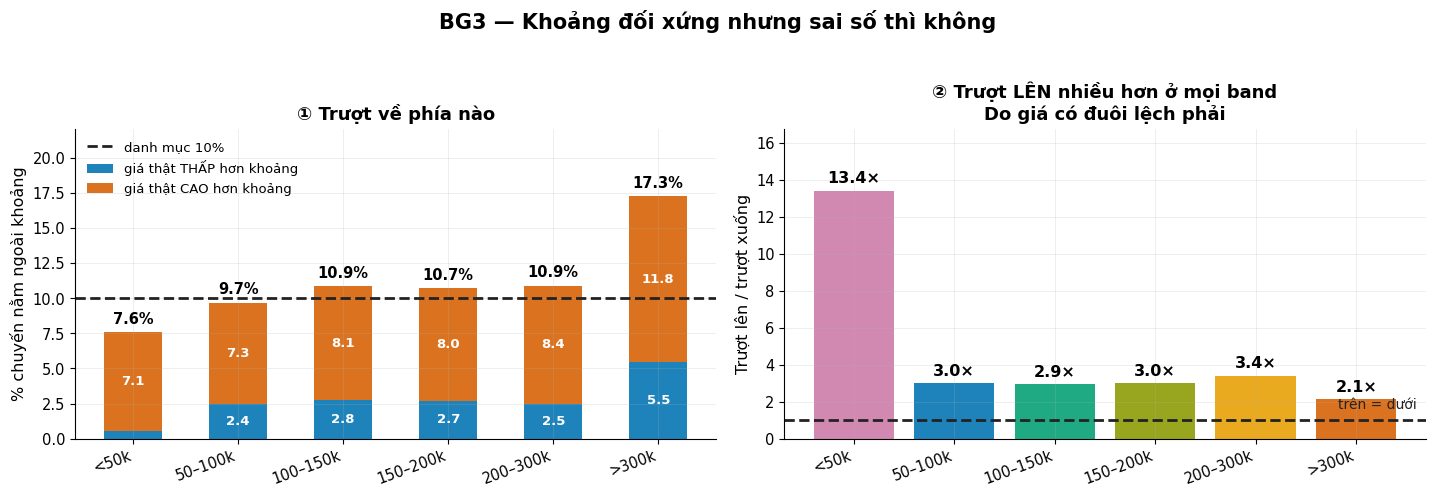

      Band   truot duoi   truot tren    ty le
----------------------------------------------
      <50k       0.53%        7.07%    13.4×
   50–100k       2.43%        7.26%     3.0×
  100–150k       2.76%        8.09%     2.9×
  150–200k       2.69%        8.03%     3.0×
  200–300k       2.47%        8.44%     3.4×
     >300k       5.49%       11.78%     2.1×


In [31]:
# ═════════ HINH BG3 — bat doi xung ═════════
fig, ax = plt.subplots(1, 2, figsize=(14.5, 4.8))

x = np.arange(len(TEN))
ax[0].bar(x, g.duoi*100, .55, color=BLUE, alpha=.88,
          label="giá thật THẤP hơn khoảng")
ax[0].bar(x, g.tren*100, .55, bottom=g.duoi*100, color=RED, alpha=.88,
          label="giá thật CAO hơn khoảng")
for i, b in enumerate(TEN):
    d_, tr = g.loc[b, "duoi"]*100, g.loc[b, "tren"]*100
    if d_ > 1:
        ax[0].text(i, d_/2, f"{d_:.1f}", ha="center", va="center", fontsize=9.5,
                   color="white", fontweight="bold")
    ax[0].text(i, d_+tr/2, f"{tr:.1f}", ha="center", va="center", fontsize=9.5,
               color="white", fontweight="bold")
    ax[0].text(i, d_+tr+.6, f"{d_+tr:.1f}%", ha="center", fontsize=10.5,
               fontweight="bold")
ax[0].axhline((1-MUC)*100, color=INK, lw=2, ls="--", label="danh mục 10%")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=20, ha="right")
ax[0].set_ylabel("% chuyến nằm ngoài khoảng")
ax[0].set_ylim(0, (g.duoi+g.tren).max()*100*1.28)
ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title("① Trượt về phía nào", fontweight="bold")

ty = (g.tren / g.duoi.replace(0, np.nan))
b2 = ax[1].bar(x, ty, color=MAU_BAND, alpha=.88)
ax[1].axhline(1, color=INK, lw=2, ls="--")
ax[1].text(len(TEN)-.4, 1.6, "trên = dưới", fontsize=10, color=INK, ha="right")
for i, v in enumerate(ty):
    if np.isfinite(v):
        ax[1].text(i, v+.4, f"{v:.1f}×", ha="center", fontsize=11.5, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN, rotation=20, ha="right")
ax[1].set_ylabel("Trượt lên / trượt xuống")
ax[1].set_ylim(0, np.nanmax(ty)*1.25)
ax[1].set_title("② Trượt LÊN nhiều hơn ở mọi band\nDo giá có đuôi lệch phải",
                fontweight="bold")

fig.suptitle("BG3 — Khoảng đối xứng nhưng sai số thì không",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BG3_bat_doi_xung.png"); plt.show()

print(f"{'Band':>10s} {'truot duoi':>12s} {'truot tren':>12s} {'ty le':>8s}")
print("-" * 46)
for b in TEN:
    r = g.loc[b]
    print(f"{b:>10s} {r.duoi:>11.2%} {r.tren:>12.2%} "
          f"{r.tren/r.duoi if r.duoi else float('nan'):>7.1f}×")

## 4. Cách sửa — Mondrian theo band giá

Vấn đề tìm ra ở Phần 1: **độ rộng tương đối y hệt 60,2% ở mọi band**, trong khi sai số thật lại
khác nhau. Cách sửa là hiệu chỉnh `q` **riêng cho từng band** — Mondrian conformal.

Không cần train lại model, chỉ lưu thêm **6 con số** thay vì 1.

q RIENG tung band (hieu chinh tren calibration):
        <50k  ±27.69%   (q chung: ±30.09%)
     50–100k  ±29.62%   (q chung: ±30.09%)
    100–150k  ±30.45%   (q chung: ±30.09%)
    150–200k  ±30.16%   (q chung: ±30.09%)
    200–300k  ±30.64%   (q chung: ±30.09%)
       >300k  ±41.01%   (q chung: ±30.09%)


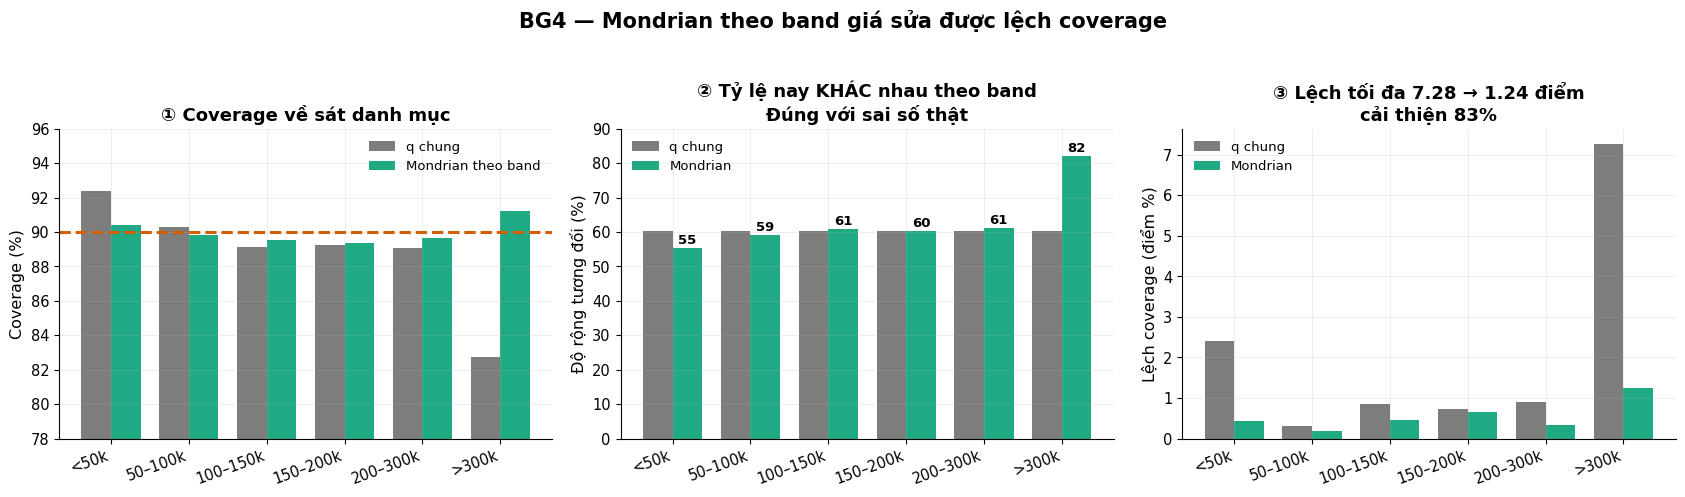


                            q chung     Mondrian
--------------------------------------------------
  Coverage tong the         89.55%       89.61%
  Lech coverage TOI DA       7.28p        1.24p
  Lech coverage TB           2.08p        0.55p
  Do rong TB                72,630d       73,012d (+0.53%)


In [32]:
q_band = uc.groupby("band", observed=True).e.quantile(MUC).reindex(TEN)
print("q RIENG tung band (hieu chinh tren calibration):")
for b in TEN:
    print(f"  {b:>10s}  ±{q_band[b]:.2%}   (q chung: ±{q90:.2%})")

M = dung_khoang(t, q_band)
gm = M.groupby("band", observed=True).agg(
    cvg=("trong", "mean"), w_med=("rong", "median"),
    rel_med=("rel", "median")).reindex(TEN)

# ═════════ HINH BG4 — Mondrian sua duoc gi ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
w = .38

ax[0].bar(x-w/2, g.cvg*100, w, color=MUT, alpha=.85, label="q chung")
ax[0].bar(x+w/2, gm.cvg*100, w, color=GREEN, alpha=.88, label="Mondrian theo band")
ax[0].axhline(MUC*100, color=RED, lw=2.2, ls="--")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=20, ha="right")
ax[0].set_ylabel("Coverage (%)"); ax[0].set_ylim(78, 96)
ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title("① Coverage về sát danh mục", fontweight="bold")

ax[1].bar(x-w/2, g.rel_med*100, w, color=MUT, alpha=.85, label="q chung")
ax[1].bar(x+w/2, gm.rel_med*100, w, color=GREEN, alpha=.88, label="Mondrian")
for i, b in enumerate(TEN):
    ax[1].text(i+w/2, gm.loc[b, "rel_med"]*100+1.2, f"{gm.loc[b,'rel_med']*100:.0f}",
               ha="center", fontsize=9.5, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN, rotation=20, ha="right")
ax[1].set_ylabel("Độ rộng tương đối (%)"); ax[1].set_ylim(0, 90)
ax[1].legend(frameon=False, fontsize=9.5)
ax[1].set_title("② Tỷ lệ nay KHÁC nhau theo band\nĐúng với sai số thật",
                fontweight="bold")

l_chung = abs(g.cvg*100 - MUC*100)
l_mon = abs(gm.cvg*100 - MUC*100)
ax[2].bar(x-w/2, l_chung, w, color=MUT, alpha=.85, label="q chung")
ax[2].bar(x+w/2, l_mon, w, color=GREEN, alpha=.88, label="Mondrian")
ax[2].set_xticks(x); ax[2].set_xticklabels(TEN, rotation=20, ha="right")
ax[2].set_ylabel("Lệch coverage (điểm %)")
ax[2].legend(frameon=False, fontsize=9.5)
ax[2].set_title(f"③ Lệch tối đa {l_chung.max():.2f} → {l_mon.max():.2f} điểm\n"
                f"cải thiện {(1-l_mon.max()/l_chung.max())*100:.0f}%",
                fontweight="bold")

fig.suptitle("BG4 — Mondrian theo band giá sửa được lệch coverage",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "BG4_mondrian_band.png"); plt.show()

print()
print(f"{'':22s} {'q chung':>12s} {'Mondrian':>12s}")
print("-" * 50)
print(f"  {'Coverage tong the':20s} {T.trong.mean():>11.2%} {M.trong.mean():>12.2%}")
print(f"  {'Lech coverage TOI DA':20s} {l_chung.max():>10.2f}p {l_mon.max():>11.2f}p")
print(f"  {'Lech coverage TB':20s} {l_chung.mean():>10.2f}p {l_mon.mean():>11.2f}p")
print(f"  {'Do rong TB':20s} {T.rong.mean():>11,.0f}d {M.rong.mean():>12,.0f}d "
      f"({M.rong.mean()/T.rong.mean()-1:+.2%})")

## Kết luận

In [33]:
print("╔" + "═"*72 + "╗")
print("║" + " UQ THEO BAND GIA — KET LUAN ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print("  1. CON SO TRUNG BINH CHE MAT VAN DE THAT")
print(f"     Coverage tong the {T.trong.mean():.2%} — nhin thi dat danh muc 90%.")
print(f"     Nhung tach theo band: {g.cvg.min():.2%} (>300k) den {g.cvg.max():.2%} (<50k)")
print(f"     -> lech {abs(g.cvg*100-90).max():.1f} diem. Nhom dat nhat bi phuc vu te nhat.")
print()
print("  2. GOC VAN DE: TY LE CUNG")
print(f"     Do rong tuong doi {g.rel_med.min():.1%}-{g.rel_med.max():.1%} — y HET nhau moi band,")
print(f"     trong khi do rong tuyet doi chenh {g.w_med.max()/g.w_med.min():.1f} lan.")
print("     Conformal chuan hoa ap MOT ty le cho tat ca -> band dat bi hut.")
print()
print("  3. SAI SO BAT DOI XUNG")
print(f"     Truot len {T.tren.mean():.2%} vs truot xuong {T.duoi.mean():.2%} "
      f"= {T.tren.mean()/T.duoi.mean():.1f} lan.")
print("     Khoang doi xung khong bat duoc duoi lech phai cua gia.")
print()
print("  4. SUA DUOC MA KHONG CAN TRAIN LAI")
print(f"     Mondrian theo band: lech toi da {l_chung.max():.2f} -> {l_mon.max():.2f} diem "
      f"({(1-l_mon.max()/l_chung.max())*100:.0f}% tot hon)")
print(f"     Do rong TB doi {M.rong.mean()/T.rong.mean()-1:+.2%}. Chi luu them 6 con so.")
print()
print("─"*74)
print("  => Cai thien UQ o day KHONG can model tot hon — chi can hieu chinh dung cach.")
print("─"*74)

╔════════════════════════════════════════════════════════════════════════╗
║                      UQ THEO BAND GIA — KET LUAN                       ║
╚════════════════════════════════════════════════════════════════════════╝

  1. CON SO TRUNG BINH CHE MAT VAN DE THAT
     Coverage tong the 89.55% — nhin thi dat danh muc 90%.
     Nhung tach theo band: 82.72% (>300k) den 92.40% (<50k)
     -> lech 7.3 diem. Nhom dat nhat bi phuc vu te nhat.

  2. GOC VAN DE: TY LE CUNG
     Do rong tuong doi 60.2%-60.2% — y HET nhau moi band,
     trong khi do rong tuyet doi chenh 7.3 lan.
     Conformal chuan hoa ap MOT ty le cho tat ca -> band dat bi hut.

  3. SAI SO BAT DOI XUNG
     Truot len 7.83% vs truot xuong 2.62% = 3.0 lan.
     Khoang doi xung khong bat duoc duoi lech phai cua gia.

  4. SUA DUOC MA KHONG CAN TRAIN LAI
     Mondrian theo band: lech toi da 7.28 -> 1.24 diem (83% tot hon)
     Do rong TB doi +0.53%. Chi luu them 6 con so.

─────────────────────────────────────────────────────

---

# Kết luận về phương pháp 1

| | |
|---|---|
| **Điểm mạnh** | Khoảng **hẹp nhất** trong ba phương pháp · đơn giản, chỉ cần lưu 1 con số · bảo đảm hữu hạn mẫu · không cần train thêm model |
| **Điểm yếu** | **Coverage điều kiện kém** — một tỷ lệ chung cho mọi chuyến nên band giá cao bị hụt · khoảng **đối xứng** trong khi sai số lệch phải |
| **Cách vá** | **Mondrian** — hiệu chỉnh `q` riêng từng nhóm. Chỉ lưu thêm vài con số, không train lại |

Xem `04_SO_SANH` để đặt phương pháp này cạnh QR và CQR.